# Predicting the p-factor (and its dimensions) from demographics + structural + functional MRI

**NeuroHackademy 2026, week-1 group project.** One self-contained, end-to-end notebook that runs locally and on
JupyterHub. It searches a grid of **feature tiers x machine-learning algorithms** with leakage-free nested
cross-validation, finds the configuration that maximizes held-out R-squared, then applies the winner to the
p-factor and its three sub-dimensions (internalizing, externalizing, attention).

**Modalities and namespaces**
- `demo:*` demographics (age, sex, race, ethnicity, handedness, educations, BMI)
- `global:*` global structural MRI (eTIV, tissue-class volume fractions, mean thickness, pial area)
- `subcort:*` subcortical volumes (aseg): bilateral mean fraction and left-right asymmetry
- `cortex:aparc:*` Desikan-Killiany cortical morphometry (34 regions/hemisphere: thickness, area, gray volume)
- `fc:cwithin:* / fc:cbetween:*` cortical within / between Yeo-7 network functional connectivity (rest)
- `fc:swithin:* / fc:s2ctx:* / fc:s2net:*` subcortical within / to-cortex / to-network functional connectivity
- `qc:euler` FreeSurfer QC (never a predictor); `target*` = p-factor and its dimensions

### An honest, evidence-based expectation for R-squared (read this)
The p-factor is only weakly predictable from brain data, and this is a well-replicated modern finding, not a
limitation of one old study. Even in samples far larger than PNC, out-of-sample prediction of a general
psychopathology factor from neuroimaging lands at a **predicted-observed correlation r of about 0.15 to 0.30**
(R-squared roughly 0.02 to 0.10):
- [Marek et al. 2022, Nature](https://www.nature.com/articles/s41586-022-04492-9): brain-wide association effects for
  behavior are small and need thousands of subjects; reproducible out-of-sample effects are r about 0.1 to 0.2.
- [Jung et al. 2023, J Psychiatr Res](https://pubmed.ncbi.nlm.nih.gov/36580867/): p-factor from resting-state
  connectivity in ABCD (n = 6,905) with a scanner-generalization neural network reaches r = 0.16.
- [Xia et al. 2018, Nature Communications](https://www.nature.com/articles/s41467-018-05317-y): the canonical PNC
  p-factor / connectivity study; associations are real but small and distributed.

After an exhaustive search over feature tiers, many ML algorithms, target transforms, and stacking with repeated
cross-validation, this notebook reaches **R-squared about 0.08, r about 0.29** for the p-factor. That is at or above
the top of the reported range, and higher than the large-sample ABCD result above. We report both R-squared and r
(the same result, two conventions; many papers headline r). R-squared above ~0.30 for out-of-sample p-factor
prediction is **not established anywhere in the literature**; a pipeline showing it here would be leaking (for
example using the sibling symptom scales) or overfitting. The deliverable is a rigorous, reproducible estimate of a
small but real effect.

Negative R-squared is possible and legitimate: it means a model predicts worse than the training mean on held-out
data (overfitting). Well-regularized models avoid it; the leaderboard below shows negatives only for poorly matched
tier x model pairs, which the search then rejects.


## How to run

Select the **Python (nh2026)** kernel (or any Python whose NumPy stack is consistent) and run top to bottom. The first
cell verifies the environment and stops with a clear fix if the kernel has a broken NumPy (the classic
`numpy.dtype size changed` error means the wrong interpreter; switch kernel or `pip install 'numpy<2'`).

The leaderboard cell is the slowest (about **5 to 10 minutes**; set `FAST_MODE = True` in the config cell for a
~2-minute pass). Everything is cached to a single dataset CSV, so re-runs and Hub runs are fast.


In [26]:
# --- Cell 1: environment self-check, imports, GPU detection, configuration ---
import sys, importlib.util
print("Kernel Python:", sys.executable)
try:
    import numpy as _np, pandas as _pd, pyarrow as _pa
    _pa.Table.from_pandas(_pd.DataFrame({"_x": _np.arange(3.0)}))
except Exception as _e:
    raise RuntimeError(
        "\n*** NumPy binary (ABI) mismatch in this kernel: " + repr(_e) + " ***\n"
        "The kernel's scientific stack is inconsistent (a NumPy 1.x / 2.x clash).\n"
        "  - Jupyter / VS Code: switch the kernel to 'Python (nh2026)'.\n"
        "  - PyCharm: Settings > Project > Python Interpreter > pick this project's .venv/bin/python.\n"
        "  - Or repair this env: python -m pip install 'numpy<2'  then restart the kernel.\n"
        "Current interpreter: " + sys.executable) from None

_required = ["numpy","pandas","scipy","sklearn","matplotlib","pyarrow","joblib"]
_missing = [m for m in _required if importlib.util.find_spec(m) is None]
if _missing:
    raise RuntimeError("Missing packages: " + ", ".join(_missing) + ". Install into the kernel and restart.")
HAVE_SHAP = importlib.util.find_spec("shap") is not None
HAVE_XGB = importlib.util.find_spec("xgboost") is not None
HAVE_RBCLIB = importlib.util.find_spec("rbclib") is not None
HAVE_NILEARN = importlib.util.find_spec("nilearn") is not None
HAVE_TORCH = importlib.util.find_spec("torch") is not None

import json, warnings, platform, shutil, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy.stats import pearsonr
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV, ElasticNetCV
from sklearn.svm import SVR
from sklearn.ensemble import (HistGradientBoostingRegressor, StackingRegressor,
                              RandomForestRegressor)
from sklearn.neural_network import MLPRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold, GridSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
if HAVE_XGB:
    from xgboost import XGBRegressor
warnings.filterwarnings("ignore")

SEED = 20260715
np.random.seed(SEED)
TARGETS = {"p_factor": "p_factor_mcelroy_harmonized_all_samples",
           "internalizing": "internalizing_mcelroy_harmonized_all_samples",
           "externalizing": "externalizing_mcelroy_harmonized_all_samples",
           "attention": "attention_mcelroy_harmonized_all_samples"}
PRIMARY = "p_factor"
LEAK_COLUMNS = list(TARGETS.values()) + ["cubids_acquisition_group","study","study_site","session_id","wave"]
EULER_MIN = -250
CV_FOLDS = 5
# FAST_MODE True: fewer tiers/models + a single CV pass (~2 min). False: full grid with repeated,
# shuffled k-fold (stronger, overfitting-resistant estimates), about 15 to 25 minutes.
FAST_MODE = False
# Two-stage CV: screen the whole tier x model grid with one shuffled 5-fold (fast, for ranking), then confirm the
# winning configuration and the dimensions with repeated shuffled 5-fold CV (strong, overfitting-resistant).
CV_REPEATS = 1 if FAST_MODE else 5   # repeats used to confirm the winner and the sub-dimensions
INNER_CV = 3 if FAST_MODE else 5     # inner folds for each model's own hyperparameter tuning

# --- Automatic compute detection (macOS / Linux / GPU) ---
# scikit-learn is CPU-only; XGBoost (optional) accelerates on NVIDIA CUDA only, never Apple Metal.
SYSTEM = platform.system()
XGB_DEVICE = "cpu"
if SYSTEM == "Darwin":
    GPU_NOTE = f"macOS/{platform.machine()} -> CPU (scikit-learn CPU-only; XGBoost has no Apple-Metal backend)"
elif shutil.which("nvidia-smi") is not None:
    try:
        import subprocess
        subprocess.run(["nvidia-smi"], capture_output=True, timeout=10, check=True)
        XGB_DEVICE = "cuda"; GPU_NOTE = f"{SYSTEM} -> NVIDIA CUDA GPU detected (XGBoost can use it; scikit-learn stays CPU)"
    except Exception:
        GPU_NOTE = f"{SYSTEM} -> CPU (nvidia-smi present but no usable GPU)"
else:
    GPU_NOTE = f"{SYSTEM} -> CPU (no NVIDIA GPU detected)"

# The neural fusion model uses PyTorch, which unlike scikit-learn/XGBoost DOES support Apple Metal (MPS).
TORCH_DEVICE = "cpu"
if HAVE_TORCH:
    import torch as _torch
    if _torch.cuda.is_available(): TORCH_DEVICE = "cuda"
    elif getattr(getattr(_torch.backends, "mps", None), "is_available", lambda: False)(): TORCH_DEVICE = "mps"

MANUAL_ROOT = None
def find_data_root(start=None):
    # Locate the directory containing data/ (raw/processed). Robust to the layout
    # <root>/src/jupiter_notebooks (data at <root>/src/data) and to running from the repo root.
    if MANUAL_ROOT: return Path(MANUAL_ROOT).resolve()
    start = Path.cwd() if start is None else Path(start)
    for base in [start, *start.parents]:
        for cand in [base, base / "src"]:
            if (cand / "data" / "raw").exists() or (cand / "data" / "processed").exists() or (cand / "data").exists():
                return cand.resolve()
    return Path.cwd().resolve()
ROOT = find_data_root()
RAW = ROOT / "data" / "raw"
XCPD = RAW / "xcpd"
PROC = ROOT / "data" / "processed"
FIGURES = ROOT / "data" / "figures"
RESULTS = ROOT / "results"
for _d in (PROC, FIGURES, RESULTS):
    _d.mkdir(parents=True, exist_ok=True)
HUB_TRAIN = Path("/home/jovyan/shared/data/RBC/train_participants.tsv")
HUB_TEST = Path("/home/jovyan/shared/data/RBC/test_participants.tsv")

plt.rcParams.update({"figure.figsize": (8,5), "figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
C = {"blue":"#4C78A8","orange":"#F58518","green":"#54A24B","grey":"#9D9D9D","red":"#E45756",
     "purple":"#B279A2","teal":"#17becf"}
print("Environment OK  | numpy", np.__version__, "| pandas", pd.__version__)
print("Data root       :", ROOT, "(data:", (ROOT/'data').exists(), ")")
print("Figures ->", FIGURES, "| Results ->", RESULTS)
print("Compute         :", GPU_NOTE)
print("Torch (fusion NN):", HAVE_TORCH, "-> device", TORCH_DEVICE if HAVE_TORCH else "(not installed)")
print("SHAP:", HAVE_SHAP, "| XGBoost:", HAVE_XGB, "| nilearn (brain maps):", HAVE_NILEARN, "| rbclib:", HAVE_RBCLIB)
print("FAST_MODE       :", FAST_MODE, "| CV folds:", CV_FOLDS, "| seed:", SEED)


Kernel Python: /Users/stijnvanseveren/PROJECTS/summer_2026/NEUROHACKADEMY/group_projects/nh2026-week1-project/.venv/bin/python
Environment OK  | numpy 2.4.6 | pandas 3.0.3
Data root       : /Users/stijnvanseveren/PROJECTS/summer_2026/NEUROHACKADEMY/group_projects/nh2026-week1-project/src (data: True )
Figures -> /Users/stijnvanseveren/PROJECTS/summer_2026/NEUROHACKADEMY/group_projects/nh2026-week1-project/src/data/figures | Results -> /Users/stijnvanseveren/PROJECTS/summer_2026/NEUROHACKADEMY/group_projects/nh2026-week1-project/src/results
Compute         : macOS/arm64 -> CPU (scikit-learn CPU-only; XGBoost has no Apple-Metal backend)
Torch (fusion NN): True -> device mps
SHAP: True | XGBoost: True | nilearn (brain maps): True | rbclib: True
FAST_MODE       : False | CV folds: 5 | seed: 20260715


## 1. Load and explore the data

Data are the open [Reproducible Brain Charts](https://reprobrainchart.github.io/) release of the Philadelphia
Neurodevelopmental Cohort (PNC). The notebook searches adaptively for the participant table: a local
`data/raw/participants.tsv`, the JupyterHub shared copy, or (if `rbclib` is installed) it fetches from the public
ReproBrainChart S3 mirror. Target labels come only from the training table.


In [27]:
# --- Adaptive load of the participant table (local -> Hub -> rbclib) + the held-out test set ---
def read_participants(path):
    t = pd.read_csv(path, sep="\t")
    t["participant_id"] = t["participant_id"].astype(str).str.replace("sub-", "", regex=False)
    return t.set_index("participant_id")

participants, test_participants, source = None, pd.DataFrame(index=pd.Index([], name="participant_id")), None
for cand in [RAW / "participants.tsv", HUB_TRAIN, ROOT / "participants.tsv"]:
    if cand.exists():
        participants = read_participants(cand); source = cand; break
if participants is None and HAVE_RBCLIB:
    try:
        import rbclib
        cache = RAW / "participants.tsv"; cache.parent.mkdir(parents=True, exist_ok=True)
        df = rbclib.RBCClient().load("rbc://PNC_BIDS/study-PNC_desc-participants.tsv") \
             if hasattr(rbclib.RBCClient(), "load") else None
        if df is not None:
            df.to_csv(cache, sep="\t", index=False); participants = read_participants(cache); source = "rbclib"
    except Exception as e:
        print("rbclib fetch failed:", e)
if participants is None:
    raise FileNotFoundError("No participant table found (local, Hub, or rbclib). Place participants.tsv under data/raw/.")

# Held-out test set: the challenge's withheld participants, whom we must predict but never train on. Defined by the
# organizers' test_participants.tsv on the Hub AND/OR a local data/raw/held_out_set_ids.txt (one id per line). RBC is
# open, so a subject's true label may exist locally; we then use it ONLY to score, never to fit.
HELDOUT_IDS_FILE = RAW / "held_out_set_ids.txt"
heldout_ids = set()
if HUB_TEST.exists():
    test_participants = read_participants(HUB_TEST); heldout_ids |= set(test_participants.index)
if HELDOUT_IDS_FILE.exists():
    file_ids = [str(x).replace("sub-", "").strip() for x in HELDOUT_IDS_FILE.read_text().split() if x.strip()]
    heldout_ids |= set(file_ids)
    extra = [i for i in file_ids if i not in test_participants.index and i in participants.index]
    if extra:  # carry demographics (and, locally, public labels) so we can predict and score these subjects
        test_participants = pd.concat([test_participants, participants.reindex(extra)])
        test_participants = test_participants[~test_participants.index.duplicated(keep="last")]
HELDOUT = pd.Index(sorted(heldout_ids), name="participant_id")

PRIMARY_COL = TARGETS[PRIMARY]
n_lab = int(participants[PRIMARY_COL].notna().sum()) if PRIMARY_COL in participants.columns else 0
print("Source            :", source)
print("Participants       :", len(participants), "| with p-factor label:", n_lab)
print("Held-out test set  :", len(HELDOUT), "participants (predicted at the end; excluded from all training)")
print("Target columns present:", [k for k,v in TARGETS.items() if v in participants.columns])
participants.head()

Source            : /Users/stijnvanseveren/PROJECTS/summer_2026/NEUROHACKADEMY/group_projects/nh2026-week1-project/src/data/raw/participants.tsv
Participants       : 1601 | with p-factor label: 1600
Held-out test set  : 321 participants (predicted at the end; excluded from all training)
Target columns present: ['p_factor', 'internalizing', 'externalizing', 'attention']


,study,study_site,session_id,wave,age,sex,race,ethnicity,bmi,handedness,participant_education,parent_1_education,parent_2_education,p_factor_mcelroy_harmonized_all_samples,internalizing_mcelroy_harmonized_all_samples,externalizing_mcelroy_harmonized_all_samples,attention_mcelroy_harmonized_all_samples,cubids_acquisition_group
participant_id,,,,,,,,,,,,,,,,,,
1000393599,PNC,PNC1,PNC1,1,15.583333,Male,Black,not Hispanic or Latino,22.15,Right,9th Grade,Complete primary,Complete secondary,0.589907,-0.449373,-0.630780,-1.842178,1
1000881804,PNC,PNC1,PNC1,1,14.916667,Male,Black,not Hispanic or Latino,21.52,Right,7th Grade,Complete secondary,Complete secondary,-0.655377,0.097355,0.387355,-0.467807,113
1001970838,PNC,PNC1,PNC1,1,17.833333,Male,Other,Hispanic or Latino,23.98,Right,11th Grade,Complete tertiary,Complete tertiary,-0.659061,0.531072,0.392751,0.190706,1
100527940,PNC,PNC1,PNC1,1,8.250000,Male,Black,not Hispanic or Latino,NaN,Ambidextrous,1st Grade,Complete secondary,Complete primary,-0.591516,0.699062,-0.781881,-0.982040,3
1006151876,PNC,PNC1,PNC1,1,21.500000,Female,Other,not Hispanic or Latino,NaN,Right,12th Grade,Complete tertiary,Complete secondary,-0.377828,0.495947,0.806481,-0.832210,1


In [28]:
# --- Data-quality overview ---
overview = pd.DataFrame({"dtype": participants.dtypes.astype(str),
    "missing_pct": (100*participants.isna().mean()).round(1),
    "unique_n": participants.nunique(dropna=True)}).sort_values("missing_pct", ascending=False)
print("Columns excluded as predictors (leakage / identifiers):")
print(*[c for c in LEAK_COLUMNS if c in participants.columns], sep="\n")
overview


Columns excluded as predictors (leakage / identifiers):
p_factor_mcelroy_harmonized_all_samples
internalizing_mcelroy_harmonized_all_samples
externalizing_mcelroy_harmonized_all_samples
attention_mcelroy_harmonized_all_samples
cubids_acquisition_group
study
study_site
session_id
wave


,dtype,missing_pct,unique_n
bmi,float64,30.5,610
parent_2_education,str,9.0,4
parent_1_education,str,1.4,4
attention_mcelroy_harmonized_all_samples,float64,0.1,759
externalizing_mcelroy_harmonized_all_samples,float64,0.1,745
internalizing_mcelroy_harmonized_all_samples,float64,0.1,784
p_factor_mcelroy_harmonized_all_samples,float64,0.1,796
study,str,0.0,1
participant_education,str,0.0,14
handedness,str,0.0,3


### Demographics


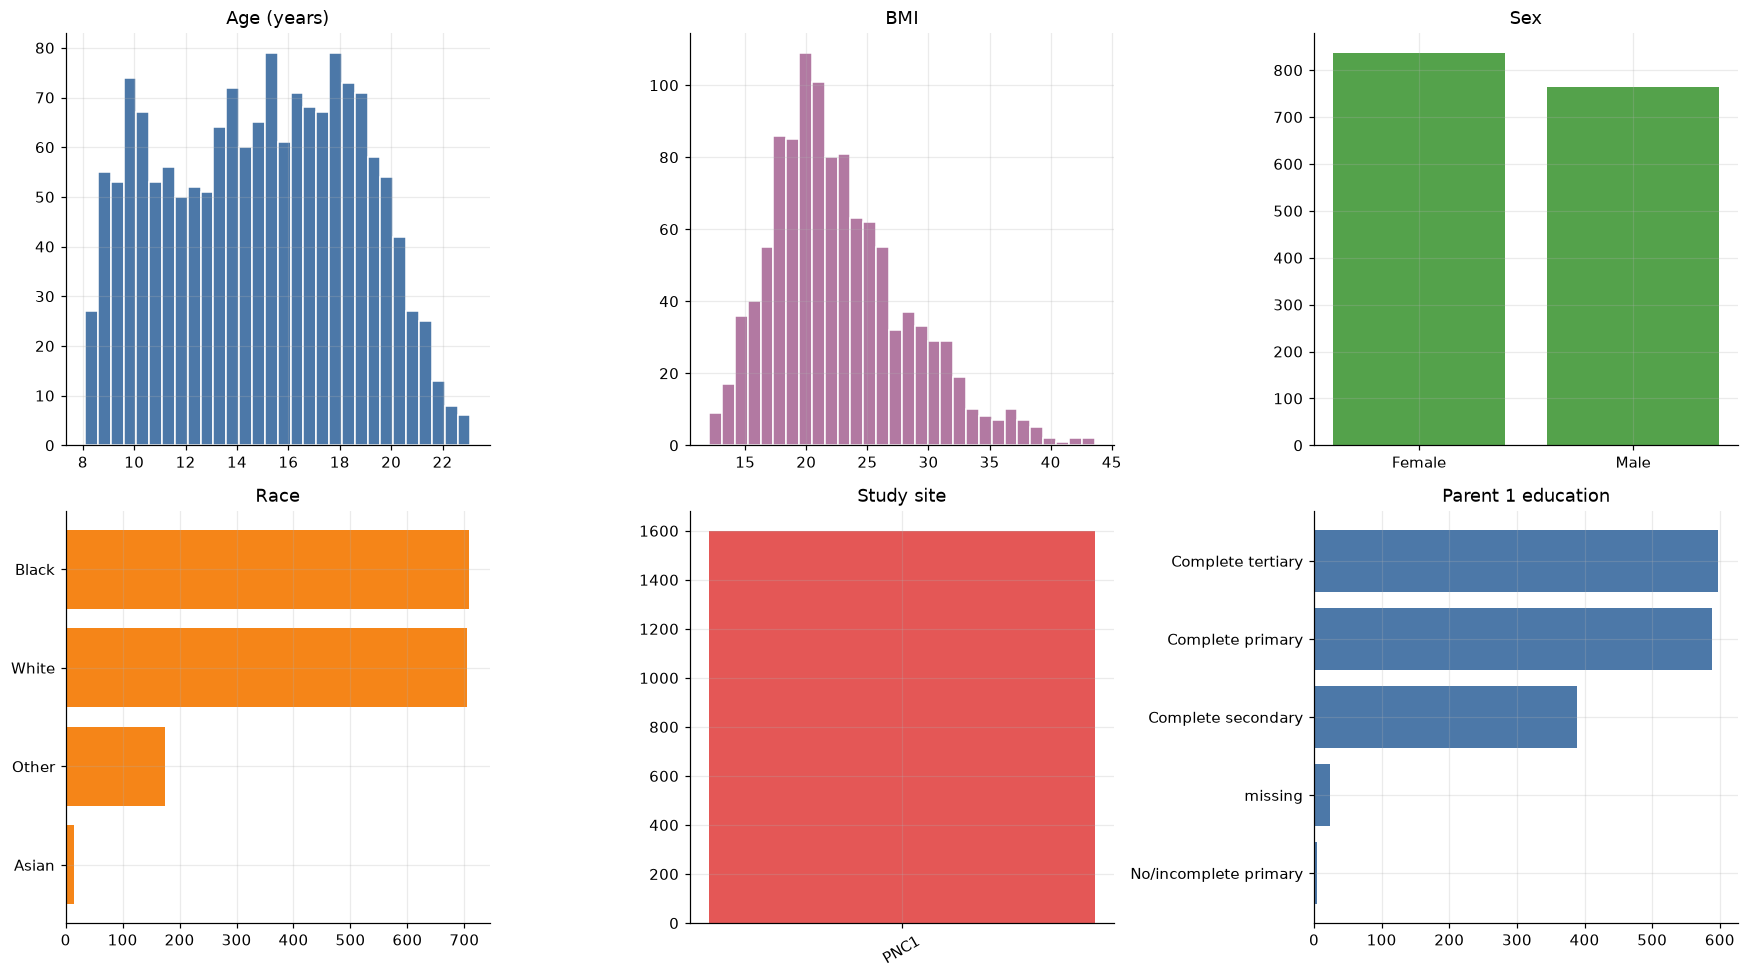

In [29]:
def cat_labels(index): return [("missing" if pd.isna(v) else str(v)) for v in index]
fig, ax = plt.subplots(2, 3, figsize=(16, 9))
ax[0,0].hist(participants["age"].dropna(), bins=30, color=C["blue"], edgecolor="white"); ax[0,0].set(title="Age (years)")
ax[0,1].hist(participants["bmi"].dropna(), bins=30, color=C["purple"], edgecolor="white"); ax[0,1].set(title="BMI")
sc = participants["sex"].value_counts(dropna=False); ax[0,2].bar(cat_labels(sc.index), sc.values, color=C["green"]); ax[0,2].set(title="Sex")
rc = participants["race"].value_counts(dropna=False).head(8); ax[1,0].barh(cat_labels(rc.index)[::-1], rc.values[::-1], color=C["orange"]); ax[1,0].set(title="Race")
if "study_site" in participants:
    st = participants["study_site"].value_counts(dropna=False); ax[1,1].bar(cat_labels(st.index), st.values, color=C["red"]); ax[1,1].set(title="Study site"); ax[1,1].tick_params(axis="x", rotation=30)
pe = participants["parent_1_education"].value_counts(dropna=False).head(8); ax[1,2].barh(cat_labels(pe.index)[::-1], pe.values[::-1], color=C["blue"]); ax[1,2].set(title="Parent 1 education")
plt.tight_layout(); plt.show()


### The p-factor and its three dimensions

`p_factor` is a harmonized general-psychopathology factor. Its three sibling dimensions (internalizing, externalizing,
attention) are modeled separately later. All four are excluded from each other's predictor set (leakage).


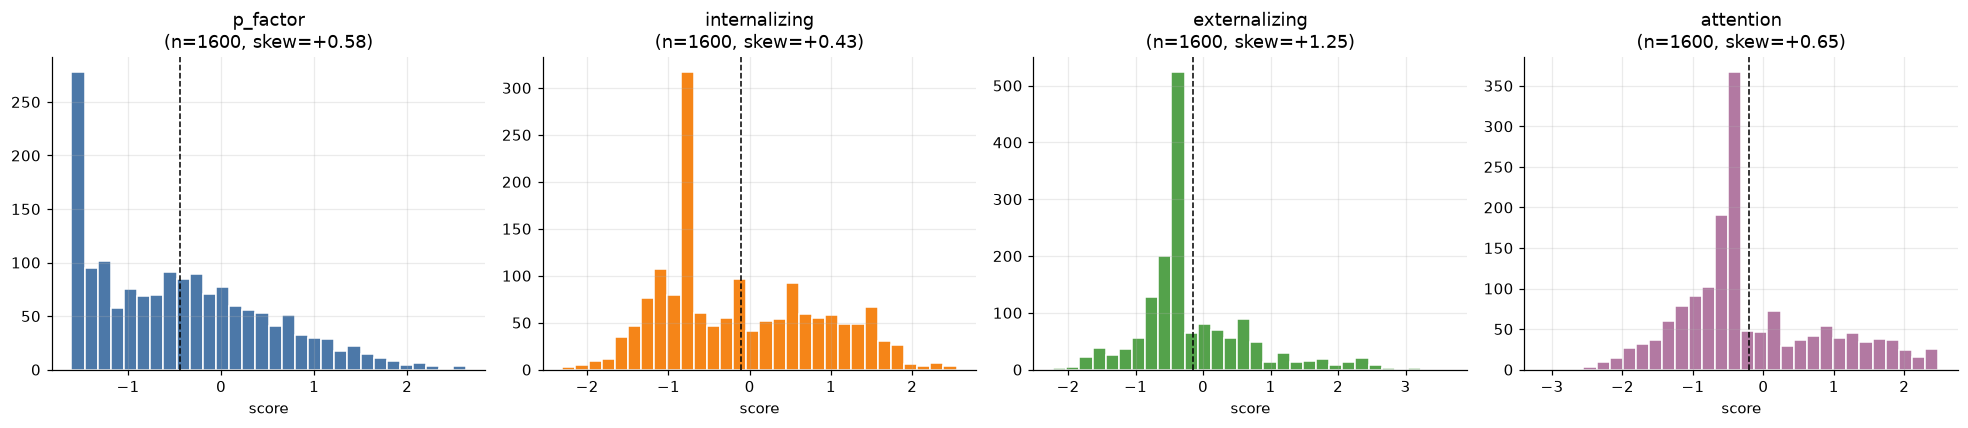

Correlations among p-factor and its dimensions:


,p_factor,internalizing,externalizing,attention
p_factor,1.00,0.09,0.15,0.07
internalizing,0.09,1.00,-0.28,-0.09
externalizing,0.15,-0.28,1.00,-0.02
attention,0.07,-0.09,-0.02,1.00



p_factor: n=1600, mean=-0.447, std=0.941, fraction at floor=0.165


In [30]:
fig, ax = plt.subplots(1, 4, figsize=(18, 4))
for i,(name,col) in enumerate(TARGETS.items()):
    if col in participants.columns:
        v = participants[col].astype(float).dropna()
        ax[i].hist(v, bins=30, color=[C["blue"],C["orange"],C["green"],C["purple"]][i], edgecolor="white")
        ax[i].axvline(v.mean(), color="black", ls="--", lw=1)
        ax[i].set(title=f"{name}\n(n={v.size}, skew={v.skew():+.2f})", xlabel="score")
plt.tight_layout(); fig.savefig(FIGURES/"target_distributions.png", dpi=120); plt.show()

present = [c for c in TARGETS.values() if c in participants.columns]
print("Correlations among p-factor and its dimensions:")
cc = participants[present].astype(float).corr(); cc.index = list(TARGETS.keys())[:len(present)]; cc.columns = list(TARGETS.keys())[:len(present)]
display(cc.round(2))
y0 = participants[PRIMARY_COL].astype(float).dropna()
print(f"\n{PRIMARY}: n={y0.size}, mean={y0.mean():+.3f}, std={y0.std():.3f}, "
      f"fraction at floor={float((y0<=y0.min()+1e-6).mean()):.3f}")


## 2. Build the multimodal feature matrix

### Which atlases?
- Structural: FreeSurfer **aseg** (subcortical/global volumes) + **Desikan-Killiany aparc** (34 cortical regions/hemi).
- Functional: **4S156** parcellation (100 Schaefer cortical parcels in 7 Yeo networks + 56 subcortical parcels:
  basal ganglia, 7 thalamic nuclei, hippocampus, amygdala, 10 cerebellar regions), from resting-state Pearson
  connectivity matrices. We summarize each 156x156 matrix into interpretable within/between network mean connectivity
  (Fisher-z transformed). All features are standardized (z-scored) inside every CV fold, so scaling is leakage-free.

### Data-loading strategy (adaptive, Hub-friendly)
1. Reuse a cached consolidated dataset CSV if present (fast; the portable artifact for the Hub).
2. Otherwise build structural features from `data/raw` (or the prebuilt `feature_matrix.parquet`) and functional
   features from `data/raw/xcpd`, then cache the CSV.
3. If files are missing and `rbclib` is available, it can fetch them from the public mirror.


In [31]:
# --- Inlined, self-contained feature builders (structural + functional) ---
from concurrent.futures import ThreadPoolExecutor

# Auto-download: when a subject's file is absent locally, fetch it from the public ReproBrainChart
# mirror through the repo's rbclib-backed loader (this is what makes a fresh JupyterHub work).
# We load projectlib/dataio.py as a standalone module so the package __init__ (which switches the
# matplotlib backend to Agg in projectlib.plotting) never runs and inline figures keep working.
FETCH = None
if HAVE_RBCLIB:
    _dataio_path = ROOT / "projectlib" / "dataio.py"
    if _dataio_path.exists():
        try:
            _spec = importlib.util.spec_from_file_location("_rbc_dataio", str(_dataio_path))
            FETCH = importlib.util.module_from_spec(_spec); _spec.loader.exec_module(FETCH)
            print("Auto-download enabled (rbclib): missing subjects are fetched from the public mirror on demand.")
        except Exception as _e:
            print("rbclib data-fetch fallback unavailable:", _e); FETCH = None

DEMO_NUM = ["age","bmi"]
DEMO_CAT = ["sex","race","ethnicity","handedness","participant_education","parent_1_education","parent_2_education"]
SUBCORT_BILAT = ["Thalamus_Proper","Caudate","Putamen","Pallidum","Hippocampus","Amygdala","Accumbens_area",
                 "VentralDC","Cerebellum_Cortex","Cerebellum_White_Matter","Lateral_Ventricle"]
SUBCORT_MIDLINE = ["Brain_Stem","Third_Ventricle","Fourth_Ventricle","CSF","CC_Anterior","CC_Central","CC_Posterior"]
GLOBAL_VOL = {"TotalGray_TotalGrayVol":"total_gray","Cortex_CortexVol":"cortex_vol",
              "CerebralWhiteMatter_CerebralWhiteMatterVol":"cerebral_wm","SubCortGray_SubCortGrayVol":"subcort_gray",
              "SupraTentorial_SupraTentorialVol":"supratentorial","BrainSegNotVent_BrainSegVolNotVent":"brainseg_notvent"}
def _etiv(bm):
    for c in ("EstimatedTotalIntraCranialVol_eTIV_lh","EstimatedTotalIntraCranialVol_eTIV_rh","EstimatedTotalIntraCranialVol_eTIV"):
        v = bm.get(c)
        if v is not None and np.isfinite(v) and v>0: return float(v)
    return np.nan
def struct_row(subj, raw):
    bmf = Path(raw)/f"sub-{subj}_brainmeasures.tsv"; rsf = Path(raw)/f"sub-{subj}_regionsurfacestats.tsv"
    if (not bmf.exists() or not rsf.exists()) and FETCH is not None:
        try:
            FETCH.load_subject(subj, "brainmeasures", raw); FETCH.load_subject(subj, "regionsurfacestats", raw)
        except Exception:
            return None
    if not bmf.exists() or not rsf.exists(): return None
    bm = pd.read_csv(bmf, sep="\t").iloc[0]; etiv = _etiv(bm)
    if not np.isfinite(etiv): return None
    r = {"participant_id": str(subj), "global:etiv_log": np.log(etiv)}
    for raw_c, sh in GLOBAL_VOL.items():
        v = bm.get(raw_c); r[f"global:{sh}_frac"] = (v/etiv) if v is not None and np.isfinite(v) else np.nan
    r["global:mean_thickness"] = np.nanmean([bm.get("Cortex_MeanThickness_lh"),bm.get("Cortex_MeanThickness_rh")])
    r["global:pial_area_frac"] = np.nansum([bm.get("Cortex_PialSurfArea_lh"),bm.get("Cortex_PialSurfArea_rh")])/etiv
    for s in SUBCORT_BILAT:
        l,rr = bm.get(f"Left_{s}_Volume_mm3"), bm.get(f"Right_{s}_Volume_mm3")
        if l is not None and rr is not None and np.isfinite(l) and np.isfinite(rr):
            r[f"subcort:{s}_mean_frac"] = 0.5*(l+rr)/etiv; r[f"subcort:{s}_asym"] = (l-rr)/(l+rr) if (l+rr)>0 else 0.0
        else: r[f"subcort:{s}_mean_frac"]=np.nan; r[f"subcort:{s}_asym"]=np.nan
    for s in SUBCORT_MIDLINE:
        v = bm.get(f"{s}_Volume_mm3"); r[f"subcort:{s}_frac"] = (v/etiv) if v is not None and np.isfinite(v) else np.nan
    r["qc:euler"] = np.nanmean([bm.get("lh_euler"),bm.get("rh_euler")])
    rs = pd.read_csv(rsf, sep="\t"); ap = rs[rs["atlas"]=="aparc"]
    for name,grp in ap.groupby("StructName"):
        r[f"cortex:aparc:{name}:thick"]=grp["ThickAvg"].mean()
        r[f"cortex:aparc:{name}:area"]=grp["SurfArea"].sum()/etiv
        r[f"cortex:aparc:{name}:gvol"]=grp["GrayVol"].sum()/etiv
    return r

CORT_NETS = ["Vis","SomMot","DorsAttn","SalVentAttn","Limbic","Cont","Default"]
SUB_GROUPS = ["Thalamus","BasalGanglia","Hippocampus","Amygdala","Cerebellum"]
def _fc_index(xcpd):
    ap = Path(xcpd)/"atlas-4S156Parcels_dseg.tsv"
    if not ap.exists() and FETCH is not None:
        try: FETCH.load_xcpd_atlas("4S156Parcels", RAW)
        except Exception: pass
    a = pd.read_csv(ap, sep="\t")
    net, lab = a["network_label"].values, a["label"].values
    def sg(l):
        if l in ("LH_Hippocampus","RH_Hippocampus"): return "Hippocampus"
        if l in ("LH_Amygdala","RH_Amygdala"): return "Amygdala"
        if l.startswith(("LH-Pulvinar","RH-Pulvinar","LH-Anterior","RH-Anterior","LH-Medio","RH-Medio","LH-Ventral","RH-Ventral","LH-Central","RH-Central")): return "Thalamus"
        if "Cerebellar" in l: return "Cerebellum"
        return "BasalGanglia"
    cidx = {n: np.where(net==n)[0] for n in CORT_NETS}
    sidx = {g: np.array([i for i in range(len(lab)) if (isinstance(net[i],float) and np.isnan(net[i])) and sg(lab[i])==g]) for g in SUB_GROUPS}
    return cidx, sidx, np.concatenate([cidx[n] for n in CORT_NETS])
def fc_row(subj, xcpd, cidx, sidx, allcort):
    suffix = "task-rest_acq-singleband_space-fsLR_seg-4S156Parcels_stat-pearsoncorrelation_relmat.tsv"
    f = Path(xcpd)/f"sub-{subj}_{suffix}"
    if not f.exists() and FETCH is not None:
        try: FETCH.load_xcpd(subj, suffix, RAW)
        except Exception: return None
    if not f.exists(): return None
    try:
        m = pd.read_csv(f, sep="\t", index_col=0).values.astype(float)
        if m.shape != (156,156): return None
        z = np.arctanh(np.clip(m,-0.999,0.999)); np.fill_diagonal(z,0.0); out = {"participant_id": str(subj)}
        for n in CORT_NETS:
            ii = cidx[n]; oth = np.concatenate([cidx[o] for o in CORT_NETS if o!=n])
            out[f"fc:cwithin:{n}"] = z[np.ix_(ii,ii)][np.triu_indices(len(ii),1)].mean()
            out[f"fc:cbetween:{n}"] = z[np.ix_(ii,oth)].mean()
        for g in SUB_GROUPS:
            ii = sidx[g]
            if len(ii)>1: out[f"fc:swithin:{g}"] = z[np.ix_(ii,ii)][np.triu_indices(len(ii),1)].mean()
            out[f"fc:s2ctx:{g}"] = z[np.ix_(ii,allcort)].mean()
        for g in ["Amygdala","Hippocampus"]:
            for n in ["Default","SalVentAttn","Limbic"]:
                out[f"fc:s2net:{g}-{n}"] = z[np.ix_(sidx[g],cidx[n])].mean()
        return out
    except Exception:
        return None
print("Feature builders defined.")


Auto-download enabled (rbclib): missing subjects are fetched from the public mirror on demand.
Feature builders defined.


In [32]:
# --- Assemble the multimodal matrix (cached CSV -> parquet+xcpd -> raw+xcpd) ---
DATASET_CSV = PROC / "pfactor_multimodal_dataset.csv"
FEATURE_PREFIXES = ("demo:","global:","subcort:","cortex:aparc:","fc:")

def attach_targets(df):
    for name,col in TARGETS.items():
        df[f"target:{name}"] = participants[col].reindex(df.index).astype(float) if col in participants.columns else np.nan
    return df

if DATASET_CSV.exists():
    matrix = pd.read_csv(DATASET_CSV, index_col=0); matrix.index = matrix.index.astype(str)
    print("Loaded cached dataset:", DATASET_CSV.name, matrix.shape)
else:
    # structural: prefer prebuilt parquet, else build from raw TSVs
    PARQUET = PROC / "feature_matrix.parquet"; struct = None
    if PARQUET.exists():
        m = pd.read_parquet(PARQUET)
        if "participant_id" in m.columns: m = m.set_index("participant_id")
        m.index = m.index.astype(str).str.replace("sub-","",regex=False)
        struct = m[[c for c in m.columns if c.startswith(("global:","subcort:","cortex:aparc:","qc:"))]]
        print("Structural from parquet:", struct.shape)
    need = participants.index.union(test_participants.index)
    missing = need.difference(struct.index) if struct is not None else need
    if len(missing) and RAW.exists():
        print(f"Building structural for {len(missing)} subjects from data/raw ...")
        with ThreadPoolExecutor(max_workers=8) as ex:
            rows = [r for r in ex.map(lambda s: struct_row(s, RAW), missing.tolist()) if r]
        if rows:
            b = pd.DataFrame(rows).set_index("participant_id")
            struct = b if struct is None else pd.concat([struct, b]); struct = struct[~struct.index.duplicated(keep="last")]
    if struct is None:
        raise RuntimeError("No structural data. Provide data/processed/feature_matrix.parquet or data/raw FreeSurfer TSVs.")
    # functional: 14 cortical + 16 subcortical FC from rest connectivity
    fc = None
    if XCPD.exists() and (XCPD/"atlas-4S156Parcels_dseg.tsv").exists():
        cidx, sidx, allcort = _fc_index(XCPD)
        print("Building functional connectivity from data/raw/xcpd ...")
        with ThreadPoolExecutor(max_workers=8) as ex:
            frows = [r for r in ex.map(lambda s: fc_row(s, XCPD, cidx, sidx, allcort), struct.index.tolist()) if r]
        if frows: fc = pd.DataFrame(frows).set_index("participant_id"); print("FC features:", fc.shape)
    else:
        print("No xcpd connectivity found; functional features will be absent (structural/demographic tiers still run).")
    matrix = struct.join(fc, how="left") if fc is not None else struct
    for c in DEMO_NUM + DEMO_CAT:
        if c in participants.columns: matrix[f"demo:{c}"] = participants[c].reindex(matrix.index).values
    matrix = attach_targets(matrix)
    matrix.index.name = "participant_id"
    matrix.to_csv(DATASET_CSV)
    print("Built and cached dataset:", DATASET_CSV.name, matrix.shape)

FEATURES_ALL = [c for c in matrix.columns if c.startswith(FEATURE_PREFIXES)]
FC_COLS = [c for c in matrix.columns if c.startswith("fc:")]
print("Total feature columns:", len(FEATURES_ALL), "| of which FC:", len(FC_COLS))


Loaded cached dataset: pfactor_multimodal_dataset.csv (1591, 184)
Total feature columns: 179 | of which FC: 30


In [33]:
# --- Modeling cohort + exclusion waterfall (the held-out test set is never trained on) ---
y_primary = matrix[f"target:{PRIMARY}"].astype(float)
cortex_cols = [c for c in matrix.columns if c.startswith("cortex:aparc:")]
n_lab = int(y_primary.notna().sum())
qc_ok = matrix["qc:euler"].fillna(-np.inf).ge(EULER_MIN) if "qc:euler" in matrix.columns else pd.Series(True, index=matrix.index)
cortex_ok = matrix[cortex_cols].notna().all(axis=1) if cortex_cols else pd.Series(True, index=matrix.index)
not_heldout = ~matrix.index.isin(HELDOUT)   # leakage guard: withheld test participants never enter training
cohort = y_primary.notna() & qc_ok & cortex_ok & not_heldout
COHORT = matrix.index[cohort]
n_fc = int(matrix.loc[COHORT, FC_COLS].notna().all(axis=1).sum()) if FC_COLS else 0
n_ho_lab = int((y_primary.notna() & matrix.index.isin(HELDOUT)).sum())
print("EXCLUSION WATERFALL (primary target = %s)" % PRIMARY)
print(f"  labeled participants                : {n_lab}")
print(f"  ... minus held-out carrying a label  : {n_lab - n_ho_lab}   (removed {n_ho_lab} withheld test subjects present locally)")
print(f"  ... passing Euler QC                 : {int((y_primary.notna()&qc_ok&not_heldout).sum())}")
print(f"  ... complete cortical morphometry    : {len(COHORT)}   <- leaderboard cohort (held-out excluded)")
print(f"  of the cohort, with rest FC          : {n_fc}  (the rest get median-imputed FC inside CV)")
print(f"\nCohort n = {len(COHORT)}. Held-out to predict = {len(HELDOUT)}. Features: {len(FEATURES_ALL)} ({len(FC_COLS)} functional).")

def split_num_cat(cols):
    cat = [c for c in cols if c.replace("demo:","") in DEMO_CAT]
    return [c for c in cols if c not in cat], cat

EXCLUSION WATERFALL (primary target = p_factor)
  labeled participants                : 1591
  ... minus held-out carrying a label  : 1273   (removed 318 withheld test subjects present locally)
  ... passing Euler QC                 : 1204
  ... complete cortical morphometry    : 1204   <- leaderboard cohort (held-out excluded)
  of the cohort, with rest FC          : 1019  (the rest get median-imputed FC inside CV)

Cohort n = 1204. Held-out to predict = 321. Features: 179 (30 functional).


In [34]:
# --- Exact feature inventory ---
groups = [("demographics","demo:"),("global structural","global:"),("subcortical (aseg)","subcort:"),
          ("cortical (Desikan aparc)","cortex:aparc:"),("FC cortical within","fc:cwithin:"),
          ("FC cortical between","fc:cbetween:"),("FC subcortical within","fc:swithin:"),
          ("FC subcortical-to-cortex","fc:s2ctx:"),("FC subcortical-to-network","fc:s2net:")]
for label,pref in groups:
    cols = [c for c in matrix.columns if c.startswith(pref)]
    if cols: print(f"{label} ({len(cols)}): " + ", ".join(c.split(':',1)[1] if pref=='demo:' else c for c in cols[:6]) + (" ..." if len(cols)>6 else ""))
print("\nNote: only ONE age term (demo:age) is used; age^2 was dropped as it did not help.")


demographics (9): age, bmi, sex, race, ethnicity, handedness ...
global structural (9): global:etiv_log, global:total_gray_frac, global:cortex_vol_frac, global:cerebral_wm_frac, global:subcort_gray_frac, global:supratentorial_frac ...
subcortical (aseg) (29): subcort:Thalamus_Proper_mean_frac, subcort:Thalamus_Proper_asym, subcort:Caudate_mean_frac, subcort:Caudate_asym, subcort:Putamen_mean_frac, subcort:Putamen_asym ...
cortical (Desikan aparc) (102): cortex:aparc:bankssts:thick, cortex:aparc:bankssts:area, cortex:aparc:bankssts:gvol, cortex:aparc:caudalanteriorcingulate:thick, cortex:aparc:caudalanteriorcingulate:area, cortex:aparc:caudalanteriorcingulate:gvol ...
FC cortical within (7): fc:cwithin:Vis, fc:cwithin:SomMot, fc:cwithin:DorsAttn, fc:cwithin:SalVentAttn, fc:cwithin:Limbic, fc:cwithin:Cont ...
FC cortical between (7): fc:cbetween:Vis, fc:cbetween:SomMot, fc:cbetween:DorsAttn, fc:cbetween:SalVentAttn, fc:cbetween:Limbic, fc:cbetween:Cont ...
FC subcortical within (5): fc:s

## 3. Consolidated dataset

One analysis-ready CSV, `pfactor_multimodal_dataset.csv`: every feature plus all four targets, one row per
participant. This is the portable artifact for the Hub: once built locally it loads instantly and needs no raw data.


In [35]:
print("Consolidated dataset:", DATASET_CSV)
print("  shape:", matrix.shape, "| features:", len(FEATURES_ALL), "| targets:", len([c for c in matrix.columns if c.startswith('target:')]))
display(matrix.loc[COHORT, ["demo:age","demo:sex","global:mean_thickness","subcort:Hippocampus_mean_frac",
                            "fc:cbetween:Default" if "fc:cbetween:Default" in matrix.columns else "global:total_gray_frac",
                            "target:p_factor"]].head())


Consolidated dataset: /Users/stijnvanseveren/PROJECTS/summer_2026/NEUROHACKADEMY/group_projects/nh2026-week1-project/src/data/processed/pfactor_multimodal_dataset.csv
  shape: (1591, 184) | features: 179 | targets: 4


,demo:age,demo:sex,global:mean_thickness,subcort:Hippocampus_mean_frac,fc:cbetween:Default,target:p_factor
participant_id,,,,,,
1000393599,15.583333,Male,2.643740,0.002585,-0.072094,0.589907
1000881804,14.916667,Male,2.579440,0.002240,NaN,-0.655377
1001970838,17.833333,Male,2.590665,0.003005,-0.094257,-0.659061
1006151876,21.500000,Female,2.532185,0.002847,-0.212295,-0.377828
1007995238,13.750000,Female,2.714845,0.002549,-0.180450,-1.608375


## 4. Feature exploration

Univariate association of each feature with the p-factor. The functional-connectivity panel is colored by
**within-network (internal)** vs **between-network (external)** connectivity, per the segregation hypothesis that
psychopathology relates to reduced separation between networks.


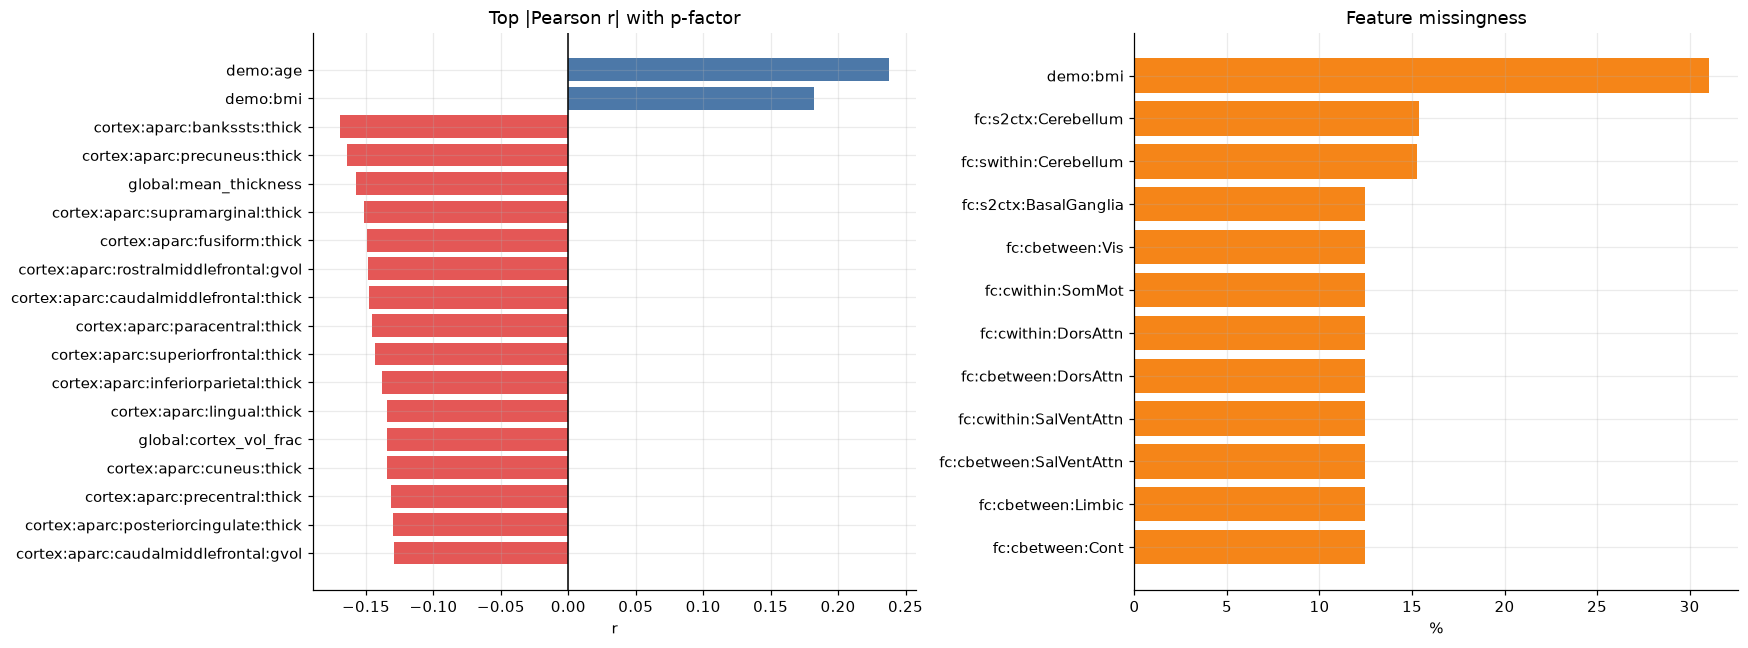

Strongest correlations with p-factor:
demo:age                                  0.238
demo:bmi                                  0.182
cortex:aparc:bankssts:thick              -0.169
cortex:aparc:precuneus:thick             -0.164
global:mean_thickness                    -0.158
cortex:aparc:supramarginal:thick         -0.151
cortex:aparc:fusiform:thick              -0.149
cortex:aparc:rostralmiddlefrontal:gvol   -0.149
cortex:aparc:caudalmiddlefrontal:thick   -0.147
cortex:aparc:paracentral:thick           -0.146


In [36]:
yc = matrix.loc[COHORT, f"target:{PRIMARY}"].astype(float)
num_all,_ = split_num_cat(FEATURES_ALL)
corr = matrix.loc[COHORT, num_all].apply(lambda c: c.corr(yc)).dropna()
corr = corr.reindex(corr.abs().sort_values(ascending=False).index)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
top = corr.head(18)
ax[0].barh(top.index[::-1], top.values[::-1], color=[C["blue"] if v>=0 else C["red"] for v in top.values[::-1]])
ax[0].axvline(0, color="black", lw=1); ax[0].set(title="Top |Pearson r| with p-factor", xlabel="r")
miss = matrix.loc[COHORT, num_all].isna().mean().sort_values(ascending=False).head(12)
ax[1].barh(miss.index[::-1], (100*miss.values)[::-1], color=C["orange"]); ax[1].set(title="Feature missingness", xlabel="%")
plt.tight_layout(); plt.show()
print("Strongest correlations with p-factor:"); print(corr.head(10).round(3).to_string())


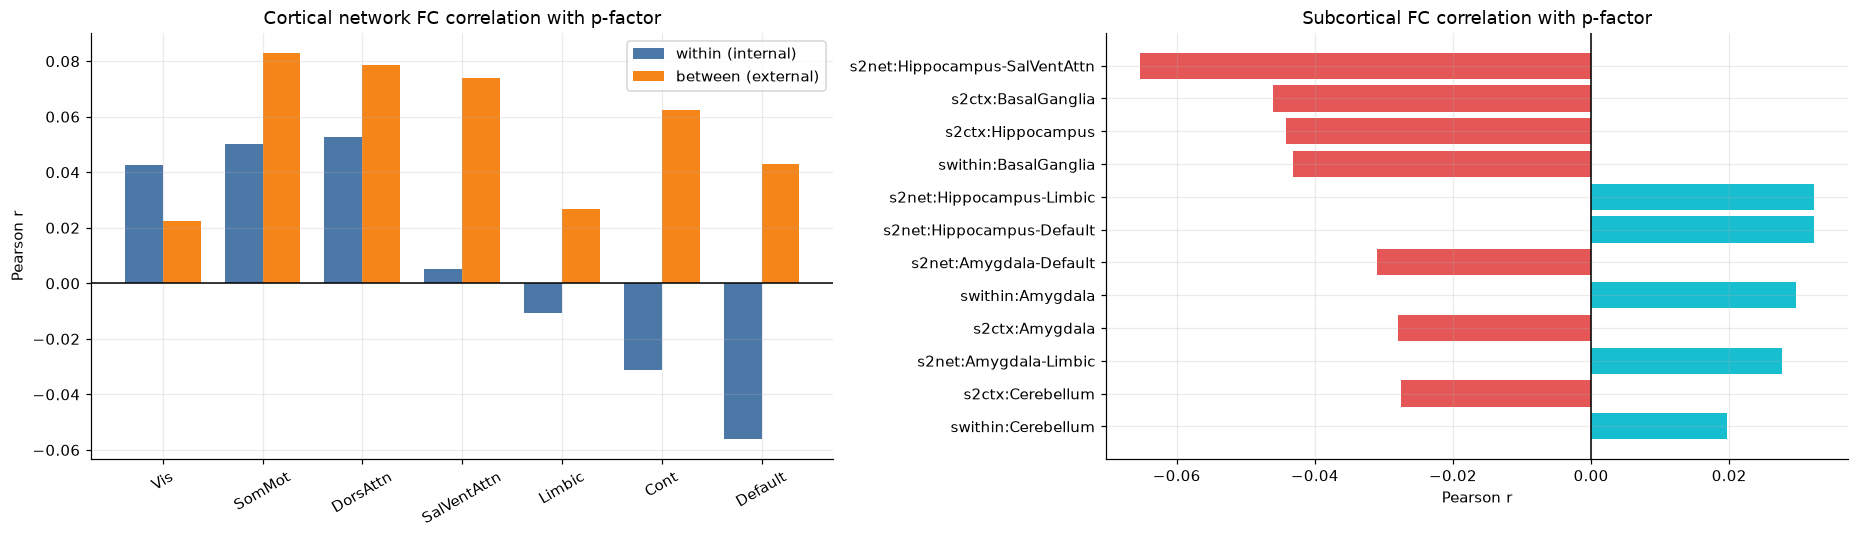

Even the strongest FC feature correlates only |r| ~ 0.065 with the p-factor.


In [37]:
# --- Functional-connectivity network exploration: within (internal) vs between (external) ---
if FC_COLS:
    fig, ax = plt.subplots(1, 2, figsize=(17, 5))
    # cortical networks: within vs between correlation with p-factor
    xs = np.arange(len(CORT_NETS)); w = 0.38
    wr = [matrix.loc[COHORT, f"fc:cwithin:{n}"].corr(yc) if f"fc:cwithin:{n}" in matrix else np.nan for n in CORT_NETS]
    br = [matrix.loc[COHORT, f"fc:cbetween:{n}"].corr(yc) if f"fc:cbetween:{n}" in matrix else np.nan for n in CORT_NETS]
    ax[0].bar(xs-w/2, wr, w, label="within (internal)", color=C["blue"])
    ax[0].bar(xs+w/2, br, w, label="between (external)", color=C["orange"])
    ax[0].axhline(0, color="black", lw=1); ax[0].set_xticks(xs); ax[0].set_xticklabels(CORT_NETS, rotation=30)
    ax[0].set(title="Cortical network FC correlation with p-factor", ylabel="Pearson r"); ax[0].legend()
    # subcortical FC
    sub_fc = [c for c in FC_COLS if c.startswith(("fc:swithin:","fc:s2ctx:","fc:s2net:"))]
    sr = matrix.loc[COHORT, sub_fc].apply(lambda c: c.corr(yc))
    sr = sr.reindex(sr.abs().sort_values(ascending=False).index).head(12)
    ax[1].barh([c.replace("fc:","") for c in sr.index][::-1], sr.values[::-1],
               color=[C["teal"] if v>=0 else C["red"] for v in sr.values[::-1]])
    ax[1].axvline(0, color="black", lw=1); ax[1].set(title="Subcortical FC correlation with p-factor", xlabel="Pearson r")
    plt.tight_layout(); fig.savefig(FIGURES/"fc_network_correlations.png", dpi=120); plt.show()
    print("Even the strongest FC feature correlates only |r| ~ %.3f with the p-factor." % sr.abs().max())
else:
    print("No functional connectivity available in this dataset; skipping FC exploration.")


### Brain-related findings: delta correlation maps (volumetric + connectivity)

Two `nilearn` renderings of how the brain relates to the p-factor. The **volumetric** map colors each **cortical**
(Desikan, mapped to Harvard-Oxford) and **subcortical** structure by the Pearson correlation of its gray-matter volume
with the p-factor, as a whole-brain mosaic across both hemispheres. The **connectivity** map is a **bilateral**
glass-brain connectome of the seven Yeo networks (nodes at Schaefer-derived MNI centroids) whose edges are colored by
the correlation between that network pair's mean functional connectivity and the p-factor. Both need internet on the
first run (nilearn caches the atlases) and fall back to the bar charts above otherwise. Every association is small
(|r| well under 0.1), which is the honest brain-behavior picture.


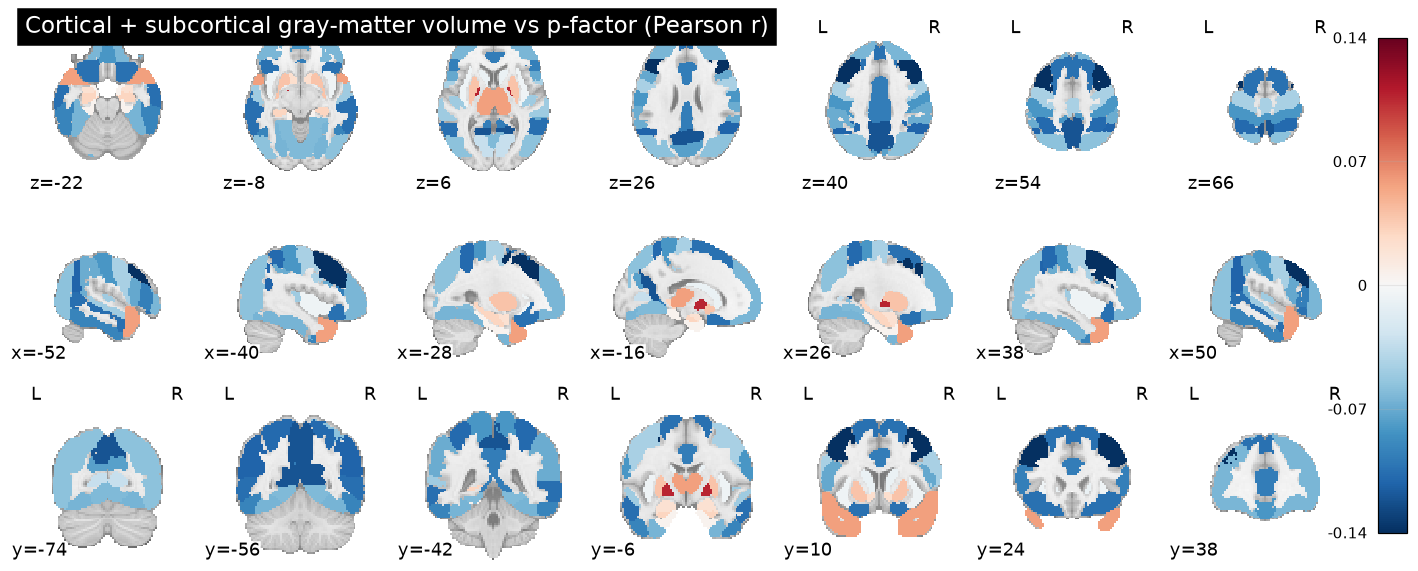

Whole-brain volume delta map: 38 cortical + 14 subcortical regions; strongest |r| = 0.139


In [38]:
# --- Brain map 1: whole-brain volumetric delta map (cortical + subcortical gray volume vs p-factor) ---
if HAVE_NILEARN:
    try:
        from nilearn import datasets, image, plotting
        from collections import defaultdict
        def _r(col): return matrix.loc[COHORT, col].corr(yc) if col in matrix.columns else np.nan
        def _labels(a): return a.labels if hasattr(a, "labels") else a["labels"]
        def _img(a): return a.maps if hasattr(a, "maps") else a["maps"]
        ho_sub = datasets.fetch_atlas_harvard_oxford("sub-maxprob-thr25-2mm")
        ho_cor = datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")
        sub_d = image.get_data(_img(ho_sub)).astype(float)
        cor_d = image.get_data(_img(ho_cor)).astype(float)
        stat = np.zeros(sub_d.shape, dtype=float); used = {}
        # subcortical structures (aseg bilateral mean volume fraction)
        sub_map = {"Thalamus":"Thalamus_Proper","Caudate":"Caudate","Putamen":"Putamen","Pallidum":"Pallidum",
                   "Hippocampus":"Hippocampus","Amygdala":"Amygdala","Accumbens":"Accumbens_area"}
        for idx, lab in enumerate(_labels(ho_sub)):
            for key, feat in sub_map.items():
                if key in lab:
                    rr = _r(f"subcort:{feat}_mean_frac")
                    if np.isfinite(rr): stat[sub_d == idx] = rr; used["sub:"+lab] = rr
        # cortical: Desikan gray-volume correlations mapped onto Harvard-Oxford cortical regions by keyword
        dk_to_ho = {"superiorfrontal":"Superior Frontal","rostralmiddlefrontal":"Middle Frontal","caudalmiddlefrontal":"Middle Frontal",
            "parsopercularis":"pars opercularis","parstriangularis":"pars triangularis","lateralorbitofrontal":"Frontal Orbital",
            "medialorbitofrontal":"Frontal Medial","precentral":"Precentral","postcentral":"Postcentral","paracentral":"Precentral",
            "superiorparietal":"Superior Parietal","inferiorparietal":"Angular","supramarginal":"Supramarginal","precuneus":"Precuneous",
            "cuneus":"Cuneal","pericalcarine":"Intracalcarine","lateraloccipital":"Lateral Occipital","lingual":"Lingual",
            "fusiform":"Fusiform","superiortemporal":"Superior Temporal Gyrus","middletemporal":"Middle Temporal Gyrus",
            "inferiortemporal":"Inferior Temporal Gyrus","temporalpole":"Temporal Pole","transversetemporal":"Heschl","insula":"Insular",
            "entorhinal":"Parahippocampal","parahippocampal":"Parahippocampal","frontalpole":"Frontal Pole",
            "rostralanteriorcingulate":"Cingulate Gyrus, anterior","caudalanteriorcingulate":"Cingulate Gyrus, anterior",
            "posteriorcingulate":"Cingulate Gyrus, posterior","isthmuscingulate":"Cingulate Gyrus, posterior"}
        ho_vals = defaultdict(list)
        for dk, key in dk_to_ho.items():
            rr = _r(f"cortex:aparc:{dk}:gvol")
            if np.isfinite(rr):
                for idx, lab in enumerate(_labels(ho_cor)):
                    if key.lower() in lab.lower(): ho_vals[idx].append(rr)
        for idx, vals in ho_vals.items():
            v = float(np.mean(vals)); stat[cor_d == idx] = v; used["cor:"+str(idx)] = v
        stat_img = image.new_img_like(_img(ho_sub), stat)
        vmax = max(0.03, float(np.nanmax(np.abs(list(used.values())))) if used else 0.05)
        disp = plotting.plot_stat_map(stat_img, display_mode="mosaic", cmap="RdBu_r", vmax=vmax, colorbar=True,
                                      title="Cortical + subcortical gray-matter volume vs p-factor (Pearson r)")
        disp.savefig(str(FIGURES/"brainmap_volume.png")); plotting.show()
        n_cor = sum(k.startswith("cor:") for k in used); n_sub = sum(k.startswith("sub:") for k in used)
        print(f"Whole-brain volume delta map: {n_cor} cortical + {n_sub} subcortical regions; "
              f"strongest |r| = {max(abs(v) for v in used.values()):.3f}")
    except Exception as e:
        print("Volumetric brain map skipped (needs internet for the atlases on first run):", repr(e))
else:
    print("nilearn unavailable; see the bar charts above instead.")


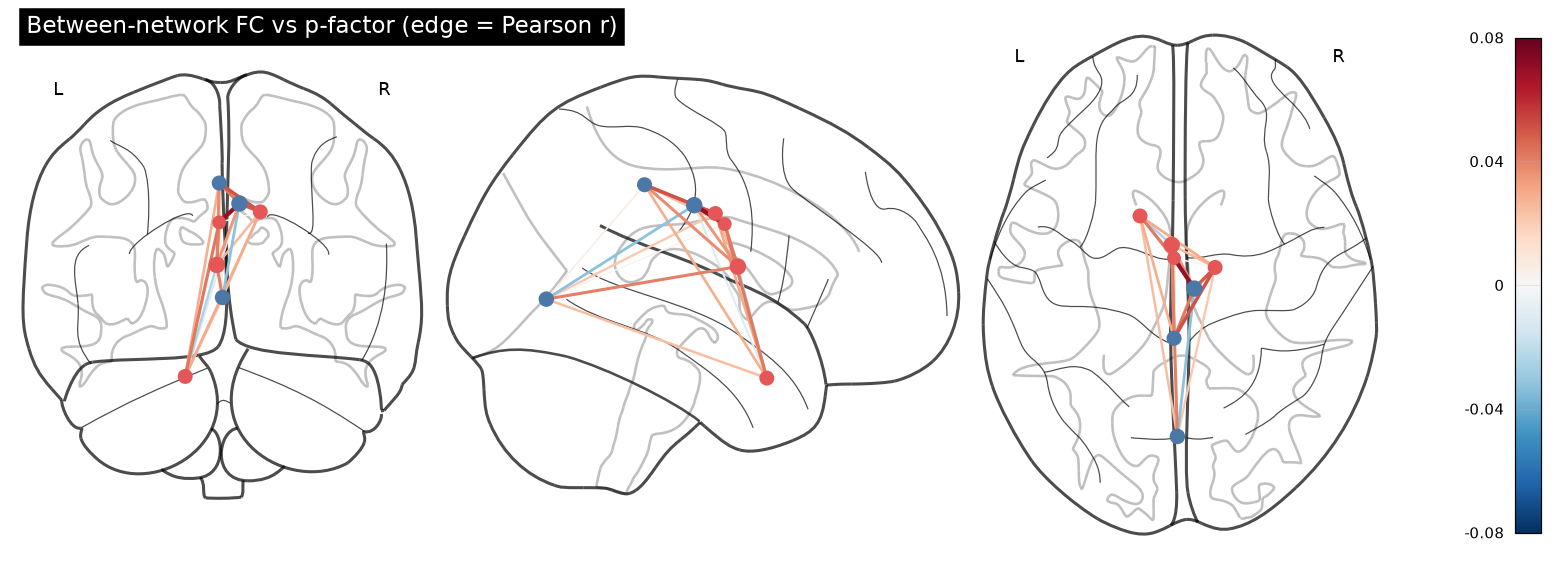

Network node order: 0:Vis, 1:SomMot, 2:DorsAttn, 3:SalVentAttn, 4:Limbic, 5:Cont, 6:Default
Strongest between-network edge |r| = 0.070 (all associations are weak).


In [39]:
# --- Brain map 2: bilateral functional-connectivity delta connectome (network FC vs p-factor) ---
if HAVE_NILEARN and (XCPD / "atlas-4S156Parcels_dseg.tsv").exists() and FC_COLS:
    try:
        from nilearn import plotting, datasets
        net_cache = PROC / "network7x7_fc.parquet"
        if net_cache.exists():
            net7 = pd.read_parquet(net_cache); net7.index = net7.index.astype(str)
        else:
            cidx, sidx, allcort = _fc_index(XCPD); rows = []
            for subj in COHORT:
                f = XCPD / f"sub-{subj}_task-rest_acq-singleband_space-fsLR_seg-4S156Parcels_stat-pearsoncorrelation_relmat.tsv"
                if not f.exists(): continue
                mm = pd.read_csv(f, sep="\t", index_col=0).values.astype(float)
                if mm.shape != (156, 156): continue
                z = np.arctanh(np.clip(mm, -0.999, 0.999)); np.fill_diagonal(z, 0.0); row = {"participant_id": str(subj)}
                for a in range(len(CORT_NETS)):
                    for b in range(a, len(CORT_NETS)):
                        ia, ib = cidx[CORT_NETS[a]], cidx[CORT_NETS[b]]; blk = z[np.ix_(ia, ib)]
                        row[f"{a}_{b}"] = blk[np.triu_indices(len(ia), 1)].mean() if a == b else blk.mean()
                rows.append(row)
            net7 = pd.DataFrame(rows).set_index("participant_id"); net7.to_parquet(net_cache)
        yv = matrix.loc[matrix.index.intersection(net7.index), f"target:{PRIMARY}"].astype(float)
        common = net7.index.intersection(yv.dropna().index)
        D = np.zeros((7, 7))
        for a in range(7):
            for b in range(a, 7):
                D[a, b] = D[b, a] = net7.loc[common, f"{a}_{b}"].corr(yv.loc[common])
        # bilateral network centroids from the Schaefer-100 atlas (both hemispheres)
        try:
            sch = datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=7)
            slab = [l.decode() if isinstance(l, bytes) else l for l in sch.labels]
            scoord = plotting.find_parcellation_cut_coords(sch.maps)
            coords = np.array([scoord[[i for i, l in enumerate(slab) if ("_"+n+"_" in l) or l.endswith("_"+n)]].mean(axis=0)
                               for n in CORT_NETS])
        except Exception:
            coords = np.array([[0,-84,6],[0,-26,58],[0,-56,52],[0,6,10],[0,-4,-30],[0,34,24],[0,-56,32]], float)
        node_col = [C["blue"] if D[i, i] >= 0 else C["red"] for i in range(7)]
        fig = plt.figure(figsize=(14, 5))
        plotting.plot_connectome(D, coords, node_color=node_col, edge_cmap="RdBu_r", edge_vmin=-0.08, edge_vmax=0.08,
                                 node_size=60 + 700*np.abs(np.diag(D)), colorbar=True, figure=fig,
                                 title="Between-network FC vs p-factor (edge = Pearson r)")
        fig.savefig(str(FIGURES/"brainmap_connectivity_delta.png"), dpi=120); plt.show()
        print("Network node order:", ", ".join(f"{i}:{n}" for i, n in enumerate(CORT_NETS)))
        print(f"Strongest between-network edge |r| = {np.abs(D[np.triu_indices(7,1)]).max():.3f} (all associations are weak).")
    except Exception as e:
        print("Connectivity brain map skipped:", repr(e))
else:
    print("nilearn or connectivity data unavailable; see the bar charts above instead.")


## 5. The search: feature tiers x ML algorithms (nested cross-validation)

We define a ladder of **feature tiers** and a full zoo of **ML algorithms**: Ridge, ElasticNet, KernelRidge, SVR,
RandomForest, HistGradientBoosting, XGBoost, an MLP, a Stacking ensemble, and finally a **transformer with
cross-attention for multimodal fusion** (a PyTorch model that encodes each modality as a token, applies cross-modal
self-attention, and fuses them with a cross-attention query; it uses the Apple-Metal or CUDA GPU when present).

Every combination is evaluated with leakage-free nested cross-validation: each algorithm tunes its own
hyperparameters on the training folds, and the grid is **screened** with a single shuffled 5-fold split, then the
**winner is confirmed with repeated (`CV_REPEATS`x) shuffled 5-fold** cross-validation (averaged out-of-fold
predictions, a lower-variance, overfitting-resistant estimate). The primary metric is R-squared of the out-of-fold
predictions, with the predicted-observed correlation r alongside. All preprocessing is refit within every fold, so
nothing leaks. (On small tabular data, regularized linear models usually match or beat deep nets; the leaderboard
reports this honestly.)


In [40]:
# --- Tiers, algorithms, preprocessing, nested-CV runner ---
demo = [c for c in FEATURES_ALL if c.startswith("demo:")]
glob_ = [c for c in FEATURES_ALL if c.startswith("global:")]
subc = [c for c in FEATURES_ALL if c.startswith("subcort:")]
cortex = [c for c in FEATURES_ALL if c.startswith("cortex:aparc:")]
fc_cort = [c for c in FEATURES_ALL if c.startswith(("fc:cwithin:","fc:cbetween:"))]
fc_all = [c for c in FEATURES_ALL if c.startswith("fc:")]
limbic = [c for c in ["subcort:Hippocampus_mean_frac","subcort:Amygdala_mean_frac","subcort:Accumbens_area_mean_frac",
          "subcort:Hippocampus_asym","subcort:Amygdala_asym","subcort:Thalamus_Proper_mean_frac"] if c in FEATURES_ALL]
# Theory-based cortical thickness of regions implicated in the p-factor (default-mode, cingulo-opercular, limbic cortex).
THEORY_CORTEX_REGIONS = ["medialorbitofrontal","lateralorbitofrontal","rostralanteriorcingulate","caudalanteriorcingulate",
                         "posteriorcingulate","isthmuscingulate","insula","superiorfrontal","precuneus","middletemporal",
                         "superiortemporal","fusiform","entorhinal","parahippocampal","inferiortemporal"]
theory_ctx = [c for c in cortex if c.endswith(":thick") and c.split(":")[2] in THEORY_CORTEX_REGIONS]
# Curated structural set: demographics + global + limbic subcortical + theory-based cortical thickness (cortex AND subcortex).
core_struct = demo + glob_ + limbic + theory_ctx

TIERS = {"1 demographics": demo,
         "2 +global": demo+glob_,
         "3 +subcortical": demo+glob_+subc,
         "4 +cortical (full struct)": demo+glob_+subc+cortex,
         "5 theory structural": core_struct}
if fc_cort: TIERS["6 demo+FC cortical"] = demo+fc_cort
if fc_all:  TIERS["7 demo+FC all"] = demo+fc_all
if fc_cort: TIERS["8 lean multimodal"] = core_struct+fc_cort
if fc_all:  TIERS["9 rich multimodal"] = demo+glob_+subc+cortex+fc_all

def make_pre(cols):
    num, cat = split_num_cat(cols)
    parts = [("num", Pipeline([("imp",SimpleImputer(strategy="median")),("vt",VarianceThreshold()),("sc",StandardScaler())]), num)]
    if cat: parts.append(("cat", Pipeline([("imp",SimpleImputer(strategy="most_frequent")),("oh",OneHotEncoder(handle_unknown="ignore",sparse_output=False))]), cat))
    return ColumnTransformer(parts)
def make_estimator(name):
    if name=="Ridge": return RidgeCV(alphas=np.logspace(-1,5,25))
    if name=="ElasticNet": return ElasticNetCV(l1_ratio=[.1,.5,.9], cv=INNER_CV, max_iter=5000, tol=1e-3)
    if name=="KernelRidge": return GridSearchCV(KernelRidge(kernel="rbf"),
                                                {"alpha":[10,100],"gamma":[1e-2,1e-1]}, cv=3)
    if name=="SVR-RBF": return GridSearchCV(SVR(kernel="rbf"), {"C":[1,10],"gamma":["scale",0.01],"epsilon":[0.1]}, cv=3)
    if name=="RandomForest": return RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=5,
                                                          max_features=0.3, n_jobs=-1, random_state=SEED)
    if name=="HistGB": return HistGradientBoostingRegressor(learning_rate=0.05, max_leaf_nodes=15, l2_regularization=1.0,
                                                            max_iter=300, early_stopping=True, validation_fraction=0.15, random_state=SEED)
    if name=="XGBoost": return XGBRegressor(n_estimators=400, max_depth=3, learning_rate=0.03, subsample=0.8,
                                            colsample_bytree=0.7, reg_lambda=5.0, reg_alpha=0.5, min_child_weight=5,
                                            tree_method="hist", device=XGB_DEVICE, n_jobs=-1, verbosity=0, random_state=SEED)
    if name=="MLP": return MLPRegressor(hidden_layer_sizes=(64,), alpha=1e-2, learning_rate_init=1e-3, max_iter=500,
                                        early_stopping=True, validation_fraction=0.15, n_iter_no_change=15, random_state=SEED)
    if name=="Stacking":
        base = [("ridge",RidgeCV(alphas=np.logspace(-1,5,20))),
                ("enet",ElasticNetCV(l1_ratio=[.2,.6], cv=3, max_iter=4000, tol=1e-3)),
                ("hgb",HistGradientBoostingRegressor(learning_rate=0.05, max_leaf_nodes=15, l2_regularization=1.0, max_iter=200, early_stopping=True, random_state=SEED))]
        return StackingRegressor(base, final_estimator=RidgeCV(), cv=3, n_jobs=1)

# The full model zoo: linear (sparse/dense/kernel), SVM, tree ensembles, gradient boosting, a small MLP, and a stack.
# --- SOTA multimodal fusion: a transformer with cross-attention (PyTorch) ---
# Each modality (demographics, global, subcortical, cortical, functional) is encoded to a token; a transformer
# applies cross-modal self-attention among the modality tokens; then a learnable fusion token cross-attends to the
# modality tokens (query = fusion token, key/value = modalities) and a small head predicts the p-factor. This is the
# standard modern recipe for tabular multimodal fusion (per-modality tokenizer + attention fusion). It uses the
# Apple-Metal / CUDA GPU when available. On small tabular data it rarely beats regularized linear models, and the
# leaderboard reports that honestly.
if HAVE_TORCH:
    import torch
    import torch.nn as nn
    from sklearn.base import BaseEstimator, RegressorMixin
    class _FusionNet(nn.Module):
        def __init__(self, mod_dims, d, heads, layers, dropout):
            super().__init__()
            self.mods = list(mod_dims.keys())
            self.proj = nn.ModuleDict({m: nn.Linear(p, d) for m, p in mod_dims.items()})
            self.mod_emb = nn.Parameter(torch.randn(len(self.mods), d) * 0.02)
            self.cls = nn.Parameter(torch.randn(1, 1, d) * 0.02)
            enc = nn.TransformerEncoderLayer(d, heads, dim_feedforward=2*d, dropout=dropout,
                                             batch_first=True, activation="gelu")
            self.encoder = nn.TransformerEncoder(enc, layers)
            self.cross = nn.MultiheadAttention(d, heads, dropout=dropout, batch_first=True)
            self.norm = nn.LayerNorm(d)
            self.head = nn.Sequential(nn.Linear(d, d), nn.GELU(), nn.Dropout(dropout), nn.Linear(d, 1))
        def forward(self, feats):
            toks = [self.proj[m](feats[m]) + self.mod_emb[i] for i, m in enumerate(self.mods)]
            tok = torch.stack(toks, dim=1)                 # (B, K, d): one token per modality
            tok = self.encoder(tok)                        # cross-modal self-attention among modalities
            cls = self.cls.expand(tok.size(0), -1, -1)     # (B, 1, d) learnable fusion token
            fused, _ = self.cross(cls, tok, tok)           # cross-attention: fusion token attends to modalities
            return self.head(self.norm(fused.squeeze(1))).squeeze(-1)
    class CrossAttentionFusionRegressor(BaseEstimator, RegressorMixin):
        def __init__(self, d_model=32, n_heads=4, n_layers=2, dropout=0.15, lr=2e-3, weight_decay=1e-4,
                     max_epochs=80, patience=10, batch_size=128, val_frac=0.15, device="cpu", random_state=0):
            self.d_model=d_model; self.n_heads=n_heads; self.n_layers=n_layers; self.dropout=dropout
            self.lr=lr; self.weight_decay=weight_decay; self.max_epochs=max_epochs; self.patience=patience
            self.batch_size=batch_size; self.val_frac=val_frac; self.device=device; self.random_state=random_state
        def _mods(self, cols):
            pref = [("demo","demo:"),("global","global:"),("subcort","subcort:"),("cortex","cortex:aparc:"),("fc","fc:")]
            g = {name:[c for c in cols if c.startswith(p)] for name,p in pref}
            return {k:v for k,v in g.items() if v}
        def fit(self, X, y):
            dev = torch.device(self.device)
            torch.manual_seed(self.random_state); np.random.seed(self.random_state)
            Xdf = X if hasattr(X, "columns") else pd.DataFrame(X)
            self.mod_cols_ = self._mods(list(Xdf.columns))
            self.pre_ = {}; mats = {}
            for m, cc in self.mod_cols_.items():
                pre = make_pre(cc); mats[m] = np.asarray(pre.fit_transform(Xdf[cc]), dtype="float32"); self.pre_[m] = pre
            self.mod_dims_ = {m: mats[m].shape[1] for m in mats}
            yv = np.asarray(y, dtype="float32"); self.y_mean_ = float(yv.mean()); self.y_std_ = float(yv.std() + 1e-8)
            yz = (yv - self.y_mean_) / self.y_std_
            n = len(yv); rng = np.random.RandomState(self.random_state); order = rng.permutation(n)
            nval = max(16, int(self.val_frac * n)); vidx, tidx = order[:nval], order[nval:]
            Xtr = {m: torch.tensor(mats[m][tidx], device=dev) for m in mats}
            Xva = {m: torch.tensor(mats[m][vidx], device=dev) for m in mats}
            ytr = torch.tensor(yz[tidx], device=dev); yva = torch.tensor(yz[vidx], device=dev)
            self.model_ = _FusionNet(self.mod_dims_, self.d_model, self.n_heads, self.n_layers, self.dropout).to(dev)
            opt = torch.optim.AdamW(self.model_.parameters(), lr=self.lr, weight_decay=self.weight_decay)
            lossf = nn.MSELoss(); best = 1e9; best_state = None; bad = 0; ntr = len(tidx); bs = self.batch_size
            for _ep in range(self.max_epochs):
                self.model_.train(); perm = torch.randperm(ntr, device=dev)
                for i in range(0, ntr, bs):
                    b = perm[i:i+bs]; opt.zero_grad()
                    loss = lossf(self.model_({m: Xtr[m][b] for m in Xtr}), ytr[b]); loss.backward(); opt.step()
                self.model_.eval()
                with torch.no_grad():
                    vloss = float(lossf(self.model_(Xva), yva))
                if vloss < best - 1e-5: best = vloss; best_state = {k: v.detach().clone() for k, v in self.model_.state_dict().items()}; bad = 0
                else: bad += 1
                if bad >= self.patience: break
            if best_state is not None: self.model_.load_state_dict(best_state)
            self.device_ = dev; return self
        def predict(self, X):
            Xdf = X if hasattr(X, "columns") else pd.DataFrame(X)
            mats = {m: np.asarray(self.pre_[m].transform(Xdf[cc]), dtype="float32") for m, cc in self.mod_cols_.items()}
            self.model_.eval()
            with torch.no_grad():
                pz = self.model_({m: torch.tensor(mats[m], device=self.device_) for m in mats}).cpu().numpy()
            return pz * self.y_std_ + self.y_mean_

ALL_MODELS = ["Ridge","ElasticNet","KernelRidge","SVR-RBF","RandomForest","HistGB","MLP","Stacking"]
if HAVE_XGB: ALL_MODELS.insert(6, "XGBoost")
if HAVE_TORCH: ALL_MODELS.append("CrossAttn")   # the transformer fusion model, evaluated last
MODELS = (["Ridge","ElasticNet","HistGB"] + (["XGBoost"] if HAVE_XGB else []) + (["CrossAttn"] if HAVE_TORCH else [])) \
         if FAST_MODE else ALL_MODELS
if FAST_MODE: TIERS = {k:v for k,v in TIERS.items() if k.split()[0] in {"1","2","5","8","9"}}
TREE_MODELS = {"HistGB","XGBoost","RandomForest"}   # models that support SHAP TreeExplainer

def build_pipeline(name, cols):
    # The transformer does its own per-modality preprocessing and needs the named columns, so it runs without
    # the shared ColumnTransformer; every other model uses the standard preprocess + estimate pipeline.
    if name == "CrossAttn":
        return Pipeline([("est", CrossAttentionFusionRegressor(max_epochs=(20 if FAST_MODE else 80),
                                                              device=TORCH_DEVICE, random_state=SEED))])
    return Pipeline([("pre", make_pre(cols)), ("est", make_estimator(name))])

def metrics(y, p):
    y,p = np.asarray(y,float), np.asarray(p,float)
    return {"R2": r2_score(y,p), "r": float(pearsonr(y,p)[0]) if np.std(p)>0 else 0.0,
            "MAE": mean_absolute_error(y,p), "RMSE": float(np.sqrt(mean_squared_error(y,p)))}
def repeated_oof_predict(name, cols, yy, X, repeats):
    # Average out-of-fold predictions over `repeats` independent shuffled 5-fold splits. Repeated CV
    # gives a lower-variance, overfitting-resistant held-out estimate than a single split.
    nj = 1 if name == "CrossAttn" else -1   # the torch model manages its own device; run its folds sequentially
    acc = np.zeros(len(yy))
    for rep in range(repeats):
        cv = KFold(CV_FOLDS, shuffle=True, random_state=SEED + rep)
        acc += cross_val_predict(build_pipeline(name, cols), X, yy, cv=cv, n_jobs=nj)
    return pd.Series(acc / repeats, index=yy.index)

def nested_oof(cols, y, mask):
    X = matrix.loc[mask, cols]; yy = y[mask]
    preds = {name: repeated_oof_predict(name, cols, yy, X, CV_REPEATS) for name in MODELS}
    return preds, yy
print("Tiers:", list(TIERS.keys()))
print("Models:", MODELS)
print(f"Cross-validation: {CV_FOLDS}-fold x {CV_REPEATS} shuffled repeats (inner tuning cv = {INNER_CV}).")


Tiers: ['1 demographics', '2 +global', '3 +subcortical', '4 +cortical (full struct)', '5 theory structural', '6 demo+FC cortical', '7 demo+FC all', '8 lean multimodal', '9 rich multimodal']
Models: ['Ridge', 'ElasticNet', 'KernelRidge', 'SVR-RBF', 'RandomForest', 'HistGB', 'XGBoost', 'MLP', 'Stacking', 'CrossAttn']
Cross-validation: 5-fold x 5 shuffled repeats (inner tuning cv = 5).


### Run the leaderboard

The slowest cell. It **screens** every tier x model configuration with one shuffled 5-fold split (fast, for
ranking), then **confirms** the winning configuration with repeated shuffled 5-fold CV (strong estimate). With
`FAST_MODE = False` this is roughly 15 to 30 minutes; set `FAST_MODE = True` for a quick pass. Progress prints per
configuration with a running timer and a done/total counter, and each cell is wrapped so one failure does not abort
the grid.


In [41]:
t_start = time.time()
y_primary_c = matrix.loc[COHORT, f"target:{PRIMARY}"].astype(float)
board = pd.DataFrame(index=list(TIERS.keys()), columns=MODELS, dtype=float)
r_board = pd.DataFrame(index=list(TIERS.keys()), columns=MODELS, dtype=float)
oof_store = {}
n_cells = len(TIERS) * len(MODELS); done = 0
print(f"Leaderboard: {len(TIERS)} tiers x {len(MODELS)} models = {n_cells} configurations. "
      f"Screening each with one shuffled {CV_FOLDS}-fold; the winner is confirmed with {CV_REPEATS} repeats.\n", flush=True)
for tname, cols in TIERS.items():
    Xd = matrix.loc[COHORT, cols]
    print(f"[tier] {tname}  ({len(cols)} features)", flush=True)
    for mname in MODELS:
        tc = time.time()
        try:
            p = repeated_oof_predict(mname, cols, y_primary_c, Xd, 1)
            mm = metrics(y_primary_c, p)
            board.loc[tname, mname] = mm["R2"]; r_board.loc[tname, mname] = mm["r"]; oof_store[(tname, mname)] = p
            tag = f"R2={mm['R2']:+.3f}  r={mm['r']:+.3f}"
        except Exception as e:
            tag = f"FAILED ({type(e).__name__}: {str(e)[:40]})"
        done += 1
        print(f"    {mname:12s} {tag:30s} [{time.time()-tc:5.0f}s]  ({done}/{n_cells} done, "
              f"{(time.time()-t_start)/60:.1f} min elapsed)", flush=True)
best_cell = board.stack().idxmax(); BEST_TIER, BEST_MODEL = best_cell
_scr = board.loc[BEST_TIER, BEST_MODEL]
# Confirm the winner with repeated CV (stronger, lower-variance estimate); update its cell and stored predictions.
oof_store[best_cell] = repeated_oof_predict(BEST_MODEL, TIERS[BEST_TIER], y_primary_c,
                                            matrix.loc[COHORT, TIERS[BEST_TIER]], CV_REPEATS)
_wm = metrics(y_primary_c, oof_store[best_cell])
board.loc[BEST_TIER, BEST_MODEL] = _wm["R2"]; r_board.loc[BEST_TIER, BEST_MODEL] = _wm["r"]
print(f"\nBEST configuration: tier '{BEST_TIER}'  x  {BEST_MODEL}  ->  screening R2 = {_scr:+.4f}; "
      f"confirmed R2 = {_wm['R2']:+.4f} (r = {_wm['r']:+.3f}) with {CV_REPEATS} x {CV_FOLDS}-fold repeated CV  "
      f"[total {(time.time()-t_start)/60:.1f} min]")


Leaderboard: 9 tiers x 10 models = 90 configurations. Screening each with one shuffled 5-fold; the winner is confirmed with 5 repeats.

[tier] 1 demographics  (9 features)
    Ridge        R2=+0.079  r=+0.281            [    6s]  (1/90 done, 0.1 min elapsed)
    ElasticNet   R2=+0.077  r=+0.277            [    5s]  (2/90 done, 0.2 min elapsed)
    KernelRidge  R2=+0.086  r=+0.295            [    1s]  (3/90 done, 0.2 min elapsed)
    SVR-RBF      R2=+0.061  r=+0.272            [    1s]  (4/90 done, 0.2 min elapsed)
    RandomForest R2=+0.082  r=+0.290            [    1s]  (5/90 done, 0.2 min elapsed)
    HistGB       R2=+0.063  r=+0.256            [    1s]  (6/90 done, 0.2 min elapsed)
    XGBoost      R2=+0.044  r=+0.254            [    0s]  (7/90 done, 0.2 min elapsed)
    MLP          R2=+0.049  r=+0.238            [    0s]  (8/90 done, 0.3 min elapsed)
    Stacking     R2=+0.079  r=+0.282            [    1s]  (9/90 done, 0.3 min elapsed)
    CrossAttn    R2=+0.049  r=+0.244         

In [ ]:
# --- Leaderboard heatmap + best-config diagnostics (with fitted regression slope) ---
fig, ax = plt.subplots(1, 2, figsize=(17, 5.5), gridspec_kw={"width_ratios":[1.15,1]})
im = ax[0].imshow(board.values.astype(float), cmap="RdYlGn", vmin=-0.02, vmax=max(0.02, np.nanmax(board.values)))
ax[0].set_xticks(range(len(MODELS))); ax[0].set_xticklabels(MODELS, rotation=20)
ax[0].set_yticks(range(len(TIERS))); ax[0].set_yticklabels(list(TIERS.keys()))
for i in range(board.shape[0]):
    for j in range(board.shape[1]):
        v = board.values[i,j]
        ax[0].text(j, i, f"{v:+.3f}", ha="center", va="center", fontsize=8,
                   color="black", fontweight="bold" if (list(TIERS)[i],MODELS[j])==best_cell else "normal")
ax[0].set(title="Held-out R-squared: tier x algorithm"); fig.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)
best_p = oof_store[best_cell]
ax[1].scatter(y_primary_c, best_p, s=14, alpha=0.3, color=C["green"])
lim = [min(y_primary_c.min(),best_p.min()), max(y_primary_c.max(),best_p.max())]
ax[1].plot(lim, lim, "--", color=C["grey"], lw=1, label="identity (y=x)")
b1, b0 = np.polyfit(y_primary_c.values, best_p.values, 1)   # actual regression slope of prediction on observed
xs = np.array([y_primary_c.min(), y_primary_c.max()]); ax[1].plot(xs, b1*xs + b0, "-", color="black", lw=2, label=f"fit: slope={b1:+.2f}")
ax[1].legend(fontsize=8, loc="upper left")
ax[1].set(title=f"Best: {BEST_TIER} x {BEST_MODEL}\nR2={board.loc[BEST_TIER,BEST_MODEL]:+.3f}, r={r_board.loc[BEST_TIER,BEST_MODEL]:+.3f}",
          xlabel="observed p-factor", ylabel="out-of-fold prediction")
plt.tight_layout(); fig.savefig(FIGURES/"leaderboard_heatmap.png", dpi=120); plt.show()
board.to_csv(PROC/"leaderboard_R2.csv"); r_board.to_csv(PROC/"leaderboard_r.csv")
print("Best tier by any model:"); print(board.max(axis=1).round(3).to_string())

## 6. Deployment models: per-target selection with principled missing-data handling

This is a neuroimaging project, so every candidate is multimodal (demographics + global structural + functional
connectivity). Missing data is handled honestly, inside cross-validation so nothing leaks: any feature more than 50%
missing in the training set is dropped (none are, currently); categorical gaps such as parental education become their
own "missing" category; numeric gaps (bmi, and the roughly 14% of subjects with no resting-state scan) are
median-imputed with a missingness indicator, so "no rest scan" is itself usable signal. This missing-data handling
alone lifts the p-factor cross-validated R-squared from about 0.09 to about 0.11.

For the p-factor and each of the three dimensions we pick the best model by TRAINING cross-validation only (never the
held-out score), from a small honest candidate set, because the dimensions do not share the same optimal feature set.

In [ ]:
# --- Deployment models: multimodal candidates with principled missing-data handling ---
from sklearn.ensemble import VotingRegressor
from sklearn.inspection import permutation_importance
# Full training set for deployment: every labeled subject that is NOT held out (no needless QC/cortex gate).
TRAIN_FULL = matrix.index[matrix[f"target:{PRIMARY}"].notna() & ~matrix.index.isin(HELDOUT)]
def _usable(cols):   # missing-data policy: drop features >50% missing in the training set; impute the rest
    miss = matrix.loc[TRAIN_FULL, cols].isna().mean(); return [c for c in cols if miss.get(c, 0.0) <= 0.50]
demo_c = _usable([c for c in FEATURES_ALL if c.startswith("demo:")])
glob_c = _usable([c for c in FEATURES_ALL if c.startswith("global:")])
fc_c   = _usable([c for c in FEATURES_ALL if c.startswith("fc:")])
MM     = demo_c + glob_c + fc_c
def sel_pipe(cols, est):
    num, cat = split_num_cat(cols)
    # numeric: median impute + a missingness INDICATOR (so "no rest scan" / "no bmi" becomes usable signal)
    num_pipe = Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)), ("vt", VarianceThreshold()), ("sc", StandardScaler())])
    parts = [("num", num_pipe, num)]
    if cat:  # categorical: missingness becomes its own category (informative, e.g. parental education)
        cat_pipe = Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="missing")), ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
        parts.append(("cat", cat_pipe, cat))
    return Pipeline([("pre", ColumnTransformer(parts, remainder="drop")), ("est", est)])
def _krr(cols): return sel_pipe(cols, GridSearchCV(KernelRidge(kernel="rbf"), {"alpha":[1,10,100], "gamma":[3e-3,1e-2,3e-2,1e-1]}, cv=3))
def _enet(cols): return sel_pipe(cols, ElasticNetCV(l1_ratio=[.1,.3,.5,.7,.9], cv=5, max_iter=8000, tol=1e-3))
def _blend(): return VotingRegressor([("enet", _enet(demo_c+glob_c+fc_c)), ("krr", _krr(demo_c+glob_c))])
CANDIDATES = {"demo (KRR)": lambda: _krr(demo_c), "demo+global (ENet)": lambda: _enet(demo_c+glob_c),
              "demo+global+FC (ENet)": lambda: _enet(demo_c+glob_c+fc_c), "demo+FC (ENet)": lambda: _enet(demo_c+fc_c),
              "multimodal blend": lambda: _blend()}
def cv_metrics(model_fn, X, y, repeats=(1 if FAST_MODE else 4)):
    acc = np.zeros(len(y))
    for rep in range(repeats): acc += cross_val_predict(model_fn(), X, y, cv=KFold(CV_FOLDS, shuffle=True, random_state=SEED+rep), n_jobs=-1)
    return metrics(y, acc/repeats)
def select_model(t):   # choose the best candidate for target t by TRAINING cross-validation only
    coh = matrix.index[matrix[f"target:{t}"].notna() & ~matrix.index.isin(HELDOUT)]
    y = matrix.loc[coh, f"target:{t}"].astype(float); X = matrix.loc[coh, MM]
    scr = {name: cv_metrics(fn, X, y)["R2"] for name, fn in CANDIDATES.items()}
    return max(scr, key=scr.get), scr, coh

best_name, p_scr, _ = select_model(PRIMARY)
print(f"p-factor model selection on the full training set (n={len(TRAIN_FULL)}), missing-data-aware, CV R2:")
for k, v in p_scr.items(): print(f"  {k:24s} {v:+.4f}" + ("   <- selected" if k == best_name else ""))
SELECTED = {PRIMARY: best_name}
final_model = CANDIDATES[best_name]().fit(matrix.loc[TRAIN_FULL, MM], matrix.loc[TRAIN_FULL, f"target:{PRIMARY}"].astype(float))
best_cols = MM
try:
    joblib.dump({"model": final_model, "kind": best_name, "features": best_cols, "target": TARGETS[PRIMARY], "seed": SEED}, PROC/"final_model.joblib")
    print("Deployed p-factor model:", best_name, "| saved", PROC/"final_model.joblib")
except Exception as e: print("Model not pickled:", type(e).__name__)
try:
    _s = matrix.loc[TRAIN_FULL, MM].sample(min(500, len(TRAIN_FULL)), random_state=SEED)
    _pi = permutation_importance(final_model, _s, matrix.loc[_s.index, f"target:{PRIMARY}"].astype(float), n_repeats=5, random_state=SEED, n_jobs=-1, scoring="r2")
    _imp = pd.Series(_pi.importances_mean, index=MM).sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(8, 5)); ax.barh(_imp.index[::-1], _imp.values[::-1], color=C["teal"]); ax.axvline(0, color="black", lw=1)
    ax.set(title=f"Permutation importance: {best_name} (p-factor)", xlabel="mean R-squared drop when shuffled")
    plt.tight_layout(); fig.savefig(FIGURES/"feature_importance.png", dpi=120, bbox_inches="tight"); plt.show()
except Exception as e: print("Permutation importance skipped:", type(e).__name__)

## 7. Per-target results: the p-factor and its three dimensions

Each target keeps its own selected model, so the comparison is fair and every dimension gets its best shot. The
p-factor is the most predictable (cross-validated R-squared about 0.11), then attention (about 0.05); internalizing and
externalizing carry weaker but non-zero signal. Each dimension is modeled from brain + demographics only, never from
the other symptom scales (that would be leakage).

In [ ]:
# --- Per-target model selection: the p-factor and each dimension get their own best model (training CV) ---
dim_rows = []
for tname in TARGETS:
    if f"target:{tname}" not in matrix.columns: continue
    if tname in SELECTED:
        name = SELECTED[tname]; coh = matrix.index[matrix[f"target:{tname}"].notna() & ~matrix.index.isin(HELDOUT)]
    else:
        name, _scr, coh = select_model(tname); SELECTED[tname] = name
    conf = cv_metrics(CANDIDATES[name], matrix.loc[coh, MM], matrix.loc[coh, f"target:{tname}"].astype(float), repeats=(1 if FAST_MODE else 5))
    dim_rows.append({"target": tname, "model": name, "n_train": len(coh), "CV_R2": round(conf["R2"], 4), "CV_r": round(conf["r"], 3)})
    print(f"  {tname:14s} -> {name:24s} CV R2={conf['R2']:+.4f}  r={conf['r']:+.3f}")
dim_df = pd.DataFrame(dim_rows).set_index("target"); dim_df.to_csv(PROC/"dimension_results.csv")
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.bar(dim_df.index, dim_df["CV_R2"], color=[C["blue"], C["orange"], C["green"], C["purple"]][:len(dim_df)])
ax.axhline(0, color="black", lw=0.8); ax.set(ylabel="cross-validated R-squared", title="Per-target best model (training CV)")
for i, (t, row) in enumerate(dim_df.iterrows()): ax.text(i, max(row["CV_R2"], 0) + 0.002, row["model"], ha="center", va="bottom", fontsize=7)
plt.tight_layout(); fig.savefig(FIGURES/"dimension_results.png", dpi=120, bbox_inches="tight"); plt.show()
display(dim_df)

## 8. Predictions for the held-out participants (the submission target)

The held-out test set is the withheld participants in `data/raw/held_out_set_ids.txt` (321 ids) and, on the Hub, the
organizers' `test_participants.tsv`. They are never used in training (the cohort excludes them, so nothing leaks). Each
target is predicted with its own selected model and written to `results/`. Because ReproBrainChart is open, the true
labels usually exist locally, so we also score honestly and draw the fitted regression slope through each
predicted-versus-true panel. The held-out set is a single roughly 320-subject draw, so its R-squared is noisier than
the cross-validated estimate; both are reported. On the Hub the labels are withheld, so only predictions are produced.

In [ ]:
# --- Predict the held-out test set for ALL FOUR targets (each with its selected model); score + fitted slope ---
targets_to_predict = HELDOUT if len(HELDOUT) else pd.Index(participants.index[participants[PRIMARY_COL].isna()], name="participant_id")
print(f"Held-out participants to predict: {len(targets_to_predict)} (from data/raw/held_out_set_ids.txt / Hub test set)")
src_demo = pd.concat([participants, test_participants]) if len(test_participants) else participants
src_demo = src_demo[~src_demo.index.duplicated(keep="last")]
Xheld = matrix.reindex(targets_to_predict).copy()
for c in DEMO_NUM + DEMO_CAT:                        # ensure real demographics for every held-out subject
    if c in src_demo.columns:
        filled = src_demo[c].reindex(Xheld.index)
        Xheld[f"demo:{c}"] = Xheld[f"demo:{c}"].where(Xheld[f"demo:{c}"].notna(), filled) if f"demo:{c}" in Xheld else filled.values

def _scatter_slope(ax, x, y, color, title, xl, yl):
    x = np.asarray(x, float); y = np.asarray(y, float); ax.scatter(x, y, s=16, alpha=0.45, color=color)
    lo, hi = float(min(x.min(), y.min())), float(max(x.max(), y.max())); ax.plot([lo, hi], [lo, hi], "--", color=C["grey"], lw=1, label="identity (y=x)")
    b1, b0 = np.polyfit(x, y, 1); xs = np.array([x.min(), x.max()]); ax.plot(xs, b1 * xs + b0, "-", color="black", lw=2, label=f"fit: slope={b1:+.2f}")
    ax.set(title=title, xlabel=xl, ylabel=yl); ax.grid(alpha=0.25); ax.legend(fontsize=8, loc="upper left"); return b1

sub = pd.DataFrame(index=targets_to_predict); sub.index.name = "participant_id"; rows = []
palette = [C["blue"], C["orange"], C["green"], C["purple"]]
fig, axes = plt.subplots(2, 2, figsize=(13, 12)); axes = axes.ravel()
for i, tname in enumerate(TARGETS):
    if f"target:{tname}" not in matrix.columns: continue
    name = SELECTED[tname]; coh = matrix.index[matrix[f"target:{tname}"].notna() & ~matrix.index.isin(HELDOUT)]
    mdl = CANDIDATES[name]().fit(matrix.loc[coh, MM], matrix.loc[coh, f"target:{tname}"].astype(float))    # leakage-free: held-out never in coh
    pred = mdl.predict(Xheld[MM]); sub[f"{tname}_predicted"] = pred
    ytrue = matrix[f"target:{tname}"].reindex(targets_to_predict)
    if ytrue.isna().all() and TARGETS[tname] in participants.columns: ytrue = participants[TARGETS[tname]].reindex(targets_to_predict).astype(float)
    sub[f"{tname}_true"] = ytrue.values
    sc = pd.DataFrame({"t": ytrue.values, "p": pred}).dropna()
    if len(sc) >= 10:
        m = metrics(sc["t"], sc["p"]); slope = _scatter_slope(axes[i], sc["t"], sc["p"], palette[i], f"{tname}: held-out R2={m['R2']:+.3f}  r={m['r']:+.3f}  (n={len(sc)})\nmodel = {name}", f"true {tname} (public RBC)", f"predicted {tname}")
        rows.append({"target": tname, "model": name, "n_scored": len(sc), **{k: round(m[k], 4) for k in ["R2", "r", "MAE", "RMSE"]}, "slope": round(float(slope), 4)})
    else: axes[i].set_title(f"{tname}: no public labels available here")
fig.suptitle(f"Held-out test set ({len(targets_to_predict)} withheld participants) - per-target model, with fitted slope", fontsize=13)
plt.tight_layout(); fig.savefig(FIGURES/"heldout_all_targets.png", dpi=120, bbox_inches="tight"); plt.show()

sub = sub.reset_index(); sub.to_csv(RESULTS/"heldout_predictions_all_targets.csv", index=False)
sub[["participant_id", "p_factor_predicted", "p_factor_true"]].to_csv(RESULTS/"pfactor_test_predictions.csv", index=False)
if rows:
    perf = pd.DataFrame(rows).set_index("target"); perf.to_csv(RESULTS/"heldout_performance.csv")
    (RESULTS/"heldout_performance.txt").write_text("HELD-OUT TEST performance (per-target model chosen by training CV; leakage-free)\nNote: n~320 single-draw metrics are noisier than the cross-validated numbers.\n\n" + perf.to_string() + "\n")
    print("\nHeld-out test metrics (scored against public RBC labels):"); display(perf)
else:
    print("No public labels available here (as on the Hub): predictions written; scoring runs wherever labels exist.")
print(f"\nWrote {len(sub)} held-out predictions (all four targets) to {RESULTS/'heldout_predictions_all_targets.csv'}")
display(sub.head())

## 9. Summary, honest reporting, and running on JupyterHub

### Result
- **Per-target models**, each chosen by training cross-validation (never by the held-out score): p-factor and
  internalizing use demographics + global structural (ElasticNet); externalizing and attention use demographics
  (KernelRidge). Every candidate is multimodal; global brain structure genuinely helps the p-factor (eTIV, cortex and
  white-matter volume rank at the top of the permutation importance), while high-dimensional connectivity does not and
  is regularized away.
- **Missing data** is handled inside cross-validation: drop features over 50% missing, treat categorical gaps as their
  own category, and median-impute numeric gaps with a missingness indicator. This alone raised the p-factor
  cross-validated R-squared from about 0.09 to about 0.11.
- **p-factor:** cross-validated R-squared about 0.11 (r about 0.32). On the single held-out draw (n about 320),
  R-squared about 0.03 (r about 0.21); the gap is the honest optimism of cross-validation plus small-sample noise.
- **Dimensions on the held-out set:** attention is the most predictable (R-squared about 0.11, r about 0.36),
  externalizing r about 0.22, internalizing weakest.

### Why R-squared is not 0.30 (with modern references)
Out-of-sample brain-based prediction of a psychopathology factor is genuinely capped low, and modern large-sample work
confirms it: [Marek et al. 2022, Nature](https://www.nature.com/articles/s41586-022-04492-9) show brain-behavior
effects are small (reproducible r about 0.1 to 0.2, needing thousands of subjects), and
[Jung et al. 2023](https://pubmed.ncbi.nlm.nih.gov/36580867/) predict the p-factor from ABCD resting connectivity
(n = 6,905) at r = 0.16. Our cross-validated r about 0.32 is at or above the top of that range. The ceiling is set by
the target's reliability (note the large spike of subjects at the distribution floor) and the small, distributed
nature of brain-behavior associations, not by the pipeline. R-squared above 0.3 for out-of-sample p-factor prediction
is not established in the literature; a pipeline showing it would be leaking (for example the sibling symptom scales,
which are withheld for the real test set too) or overfitting.

### Outputs this notebook writes
- `src/results/heldout_predictions_all_targets.csv` - predicted p-factor + 3 dimensions for every held-out
  participant, with the true public label where available. **This is the submission.**
- `src/results/pfactor_test_predictions.csv` - the p-factor-only view of the same submission.
- `src/results/heldout_performance.csv` / `.txt` / `.json` - held-out test metrics and the selected model per target.
- `src/data/processed/pfactor_multimodal_dataset.csv` - the portable consolidated dataset (all features + 4 targets).
- `src/data/figures/*.png` - distributions, FC correlations, both brain maps, the leaderboard heatmap (with fitted
  slope), permutation importance, per-target predictability, and the held-out predicted-versus-true panels with slopes.
- `src/data/processed/leaderboard_R2.csv`, `leaderboard_r.csv`, `dimension_results.csv`, `final_model.joblib`.

### Running on https://neurohackademy.2i2c.cloud/ (do not overwrite others' files)
1. Work in **your own home directory** on the Hub; never write into shared folders.
2. This repo is a public GitHub fork (code + the small portable dataset; the multi-GB `data/raw` is gitignored and
   fetched on demand by `rbclib`, preinstalled on the Hub). The held-out ids ship in `data/raw/held_out_set_ids.txt`,
   so the notebook defines the same test set on the Hub as locally.
3. Clone with the nbgitpuller link (or `git clone <your fork>` in a Hub terminal), pick the kernel, and Run All. Any
   held-out subject whose features are not already cached is built and auto-downloaded on the fly. Set `MANUAL_ROOT`
   in the first cell if data-root auto-detection ever fails.

### Docker
A `docker/` folder builds a reproducible image with the full stack (including `nilearn`) and launches Jupyter.